# MIVA-KNIGHT — Pipeline E: Multimodal Fusion Model
## CMU-MOSI | Text + Audio + Video | Cross-Modal Transformer Fusion

### What This Notebook Does

Pipeline E is the first MIVA-KNIGHT pipeline where **text, audio, and video
from the same utterance are processed simultaneously** in a single model.

### Data Already on Your Drive

| Folder | Contents |
|---|---|
| `Data/CMU-MOSI/Transcript/Segmented/` | 93 `.annotprocessed` files |
| `Data/CMU-MOSI/Audio/WAV_16000/Segmented/` | 2,184 `.wav` files |
| `Data/CMU-MOSI/Video/Segmented/` | 2,199 `.mp4` files |

No download needed. Labels are derived from the transcript text using
TextBlob polarity mapped to the CMU-MOSI [-3, +3] scale, using the
standard published train/valid/test split by video ID.

**Run every cell top to bottom. Do not skip.**


---

### Extended scope (Part II)

After training Pipeline~E, the notebook runs the **five multimodal challenges** (representation, translation via Whisper WER, fusion metrics, co-learning gap, alignment/DTW), builds a **knowledge graph** from CMU-MOSI training transcripts, runs **hybrid RAG** (FAISS + graph boost per thesis / Month~1 notebook), and plots a **cross-challenge metric comparison**.

**Strict data policy:** segments must have **both** `.wav` and `.mp4` on disk; audio/video encoding **fails loudly** if files are missing (no silent silence or gray-frame fallbacks). OpenCV is **required** for video.


---
## Cell 1 — Package Installation

### Technical
Installs all Python dependencies required by Pipeline E in a single silent (`-q`) `pip` invocation:

| Package | Role in Pipeline E |
|---------|-------------------|
| `transformers` | HuggingFace hub — loads BERT (`bert-base-uncased`) and Wav2Vec 2.0 (`wav2vec2-base-960h`) |
| `torchaudio` | WAV file loading and on-the-fly resampling to 16 kHz |
| `torchvision` | ResNet-50 backbone for video-frame projection |
| `opencv-python` | MP4 video decoding to extract the middle frame |
| `soundfile` | Backend for reading WAV files when `torchaudio` delegates I/O |
| `scipy` | Provides `pearsonr` for Pearson correlation metric |
| `scikit-learn` | `accuracy_score` and `f1_score` for binary classification metrics |
| `textblob` | Rule-based sentiment polarity used to derive pseudo-labels from raw transcripts |

`TextBlob` also requires its NLTK corpora, downloaded via `subprocess` immediately after installation.

### Simple
Think of this as the *shopping list* step — before baking the cake, you collect all ingredients from the store. Every tool the rest of the notebook depends on is fetched here so the remaining cells run without missing-package errors.


In [1]:
!pip install -q transformers torchaudio torchvision opencv-python soundfile scipy scikit-learn textblob faiss-cpu openai-whisper
import subprocess
subprocess.run(['python', '-m', 'textblob.download_corpora'], capture_output=True)
print('All packages installed (including faiss-cpu, openai-whisper)')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 15.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 65.8 MB/s eta 0:00:00
All packages installed (including faiss-cpu, openai-whisper)


---
## Cell 2 — Imports, Device Selection & Reproducibility

### Technical

#### Reproducibility via Random Seeding
Sets **deterministic initial conditions** for both PyTorch and NumPy:
```
torch.manual_seed(42)   # seeds the CPU RNG
np.random.seed(42)      # seeds NumPy's Mersenne Twister
```
This does **not** guarantee full bit-identical reproducibility on GPU (due to non-deterministic CUDA kernels), but it stabilises weight initialisations, data-shuffling order, and dropout masks.

#### Device Selection
```python
device = 'cuda' if torch.cuda.is_available() else 'cpu'
```
All tensors and models are later moved to `device` with `.to(device)`. On the Colab T4 GPU this yields ~25× speedup over CPU for transformer inference.

#### Import Taxonomy

| Module | What it provides |
|--------|------------------|
| `torch`, `torch.nn`, `torch.nn.functional` | Core tensor ops, layer classes, activation functions |
| `torch.utils.data` | `Dataset` / `DataLoader` abstractions |
| `torch.optim` | `AdamW` optimiser |
| `torchaudio`, `torchvision` | Modality-specific I/O and pretrained models |
| `transformers` | `BertModel`, `BertTokenizer`, `Wav2Vec2Model`, `Wav2Vec2Processor` |
| `scipy.stats.pearsonr` | Pearson $r$ correlation coefficient |
| `sklearn.metrics` | Binary accuracy and weighted F1 |
| `textblob.TextBlob` | Rule-based sentiment polarity |
| `cv2` (optional) | OpenCV video capture; gracefully disabled if absent |

### Simple
Imagine setting up a workspace before a big project: you pick which computer (GPU or CPU) to work on, lay out all your tools (libraries) on the table, and set a fixed starting point for any random decisions so results can be reproduced later.


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import numpy as np
import os, json, warnings
from tqdm.auto import tqdm
from collections import defaultdict
import matplotlib.pyplot as plt
import torchaudio
import torchvision.models as models
from torchvision import transforms
from torchvision.models import ResNet50_Weights
from transformers import (BertModel, BertTokenizer,
                          Wav2Vec2Model, Wav2Vec2Processor)
from PIL import Image
from scipy.stats import pearsonr
from sklearn.metrics import f1_score, accuracy_score
from textblob import TextBlob
try:
    import cv2
    CV2_AVAILABLE = True
except ImportError:
    CV2_AVAILABLE = False
warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device  : {device}')
if device == 'cuda':
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
print(f'PyTorch : {torch.__version__}')
print(f'cv2     : {"available" if CV2_AVAILABLE else "not available"}')
print('All imports complete')


Device  : cuda
GPU     : Tesla T4
VRAM    : 15.6 GB
PyTorch : 2.10.0+cu128
cv2     : available
All imports complete


---
## Cell 3 — Google Drive Mount, PyTorch Patch & Hyperparameter Constants

### Technical

#### PyTorch 2.6 Compatibility Patch
PyTorch 2.6 changed the default behaviour of `torch.load` to `weights_only=True`, which breaks loading of arbitrary checkpoint dictionaries.  
The monkey-patch below restores backward compatibility:
```python
_orig = torch.load
def _patched(f, *a, **kw):
    kw.setdefault('weights_only', False)   # override only if caller did not specify
    return _orig(f, *a, **kw)
torch.load = _patched
```

#### Hyperparameter Registry

| Symbol | Value | Mathematical Role |
|--------|-------|-------------------|
| `EMBED_DIM` $d$ | 512 | Shared embedding dimensionality for all three modalities |
| `FUSION_HEADS` $h$ | 8 | Number of self-attention heads: each head attends over $d/h = 64$ dimensions |
| `FUSION_LAYERS` $L$ | 2 | Depth of the Transformer encoder |
| `FUSION_FF_DIM` | 1024 | Feed-forward hidden size ($2\times d$) |
| `DROPOUT` $p$ | 0.1 | Probability of zeroing activations during training |
| `NUM_EPOCHS` | 20 | Training iterations over the full dataset |
| `BATCH_SIZE` $B$ | 32 | Samples per gradient update |
| `LR` $\eta$ | $10^{-4}$ | Initial learning rate for AdamW |
| `WEIGHT_DECAY` $\lambda$ | 0.01 | L2 regularisation coefficient |
| `ALPHA` $\alpha$ | 0.6 | MSE loss weight in multi-task loss |
| `BETA` $\beta$ | 0.4 | BCE loss weight in multi-task loss |
| `MAX_TEXT_LEN` | 64 | BERT tokeniser maximum token length |

### Simple
This cell is the *control panel*. It connects the notebook to your Google Drive (where the data and saved models live) and defines all the dials and knobs that control how the model trains — like how many passes through the data, how fast to learn, and how to split the loss between two tasks.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

# PyTorch 2.6 patch
import torch as _torch
_orig = _torch.load
def _patched(f, *a, **kw):
    kw.setdefault('weights_only', False)
    return _orig(f, *a, **kw)
_torch.load = _patched
print('PyTorch 2.6 patch applied')

BASE           = '/content/drive/MyDrive/ Oluwakayode Soyinka IT 581 Project '

assert os.path.isdir(BASE), (
    f'Project root not found: {BASE!r}. Update BASE to your Drive path.'
)
MOSI_ROOT      = os.path.join(BASE, 'Data', 'CMU-MOSI')
TRANSCRIPT_DIR = os.path.join(MOSI_ROOT, 'Transcript', 'Segmented')
AUDIO_DIR      = os.path.join(MOSI_ROOT, 'Audio', 'WAV_16000', 'Segmented')
VIDEO_DIR      = os.path.join(MOSI_ROOT, 'Video', 'Segmented')
CACHE_DIR      = os.path.join(BASE, 'Data', 'mosi_cache')
CACHE_FILE     = os.path.join(CACHE_DIR, 'mosi_emb_cache.pt')
PIPELINE_A_DIR = os.path.join(BASE, 'models', 'miva_knight_month1')
PIPELINE_D_DIR = os.path.join(BASE, 'models', 'miva_knight_pipelineD')
PIPELINE_E_DIR = os.path.join(BASE, 'models', 'miva_knight_pipelineE')
CHECKPOINT     = os.path.join(PIPELINE_E_DIR, 'checkpoint_pipelineE.pth')
for d in [CACHE_DIR, PIPELINE_E_DIR]: os.makedirs(d, exist_ok=True)

EMBED_DIM     = 512
FUSION_HEADS  = 8
FUSION_LAYERS = 2
FUSION_FF_DIM = 1024
DROPOUT       = 0.1
NUM_EPOCHS    = 20
BATCH_SIZE    = 32
LR            = 1e-4
WEIGHT_DECAY  = 0.01
ALPHA         = 0.6
BETA          = 0.4
MAX_TEXT_LEN  = 64

assert os.path.exists(BASE), f'Project folder not found: {BASE}'
for name, path in [('Transcripts', TRANSCRIPT_DIR),
                   ('Audio .wav ', AUDIO_DIR),
                   ('Video .mp4 ', VIDEO_DIR)]:
    print(f'  {name}: {len(os.listdir(path)):,} files')
print(f'Pipeline E dir: {PIPELINE_E_DIR}')


Mounted at /content/drive
PyTorch 2.6 patch applied
  Transcripts: 93 files
  Audio .wav : 2,199 files
  Video .mp4 : 2,199 files
Pipeline E dir: /content/drive/MyDrive/ Oluwakayode Soyinka IT 581 Project /models/miva_knight_pipelineE


---
## Cell 4 — Build Sample List with Sentiment Labels

### Technical

#### Label Derivation via TextBlob Polarity
The CMU-MOSI gold labels (annotated on $[-3, +3]$) are unavailable without the `.pkl` file.  
A **pseudo-label** is computed from transcript text:

$$\text{label} = \text{clip}\!\left(\text{polarity}(\text{text}) \times 3,\; -3,\; +3\right)$$

where $\text{polarity} : \text{string} \to [-1, +1]$ is TextBlob's rule-based sentiment score.  
The linear scaling maps TextBlob's $[-1,+1]$ range to CMU-MOSI's $[-3,+3]$ range.

**Binary label:**
$$\text{binary} = \mathbf{1}[\text{label} > 0]$$

#### Train / Valid / Test Split
Follows the **standard CMU-MOSI split by video ID**:
- Train: 59 video IDs → 1,521 segments
- Valid: 15 video IDs → 314 segments  
- Test: 19 video IDs → 364 segments

Video-level splits prevent data leakage (segments from the same speaker/video cannot appear in both train and test).

#### Algorithm: `build_samples()`
```
for each .annotprocessed file in TRANSCRIPT_DIR:
    vid_id  ← filename without extension
    split   ← lookup in {TRAIN_VIDS, VALID_VIDS, TEST_VIDS}
    for each line in file:
        parse: seg_num _DELIM_ text
        label   ← clip(TextBlob(text).polarity × 3, −3, +3)
        binary  ← 1 if label > 0 else 0
        wav_path ← AUDIO_DIR / {vid_id}_{seg_num}.wav
        mp4_path ← VIDEO_DIR / {vid_id}_{seg_num}.mp4
        append sample dict
```

### Simple
Think of this as *reading the subtitles file* for every video clip and giving each clip a mood score.  
TextBlob reads the words and guesses whether they're positive or negative (like a very fast human reader), then that score is stretched to match the official scale used in the CMU-MOSI dataset.  
Each clip also gets tagged as either *train*, *validation*, or *test* to prevent the model from being tested on videos it already saw during training.


In [4]:
TRAIN_VIDS = {
    '2WGyTLYerpo','vvZ4IcEtiZc','dq3Nf_lMPnE','Clx4VXItLTE',
    'phBUpBr1hSo','Jkswaaud0hk','Bfr499ggo-0','Sqr0AcuoNnk',
    'lXPQBPVc5Cw','GWuJjcEuzt8','tIrG4oNLFzE','wMbj6ajWbic',
    'nzpVDcQ0ywM','rnaNMUZpvvg','Af8D0E4ZXaw','VbQk4H8hgr0',
    'bOL9jKpeJRs','c5xsKMxpXnc','d6hH302o4v8','yvsjCA6Y5Fc',
    'c7UH_rxdZv4','BioHAh1qJAQ','BXuRRbG0Ugk','cXypl4FnoZo',
    'yDtzw_Y-7RU','9T9Hf74oK10','BI97DNYfe5I','k5Y_838nuGo',
    '8d-gEyoeBzc','atnd_PF-Lbs','Oz06ZWiO20M','cW1FSBF59ik',
    'etzxEpPuc6I','LSi-o-IrDMs','bvLlb-M3UXU','f9O3YtZ2VfI',
    '8OtFthrtaJM','I5y0__X72p0','BvYR0L6f2Ig','8qrpnFRGt2A',
    'Nzq88NnDkEk','1DmNV9C1hbY','VCslbP0mgZI','Ci-AH39fi3Y',
    '9J25DZhivz8','d3_k5Xpfmik','G6GlGvlkxAQ','jUzDDGyPkXU',
    'Qr1Ca94K55A','tmZoasNr4rU','QN9ZIUWUXsY','0h-zjBukYpk',
    'G-xst2euQUc','IumbAb8q2dM','9c67fiY0wGQ','WKA5OygbEKI',
    'HEsqda8_d0Q','nbWiPyCm4g0','cM3Yna7AavY',
}
VALID_VIDS = {
    'pLTX3ipuDJI','zhpQhgha_KU','9qR7uwkblbs','ZAIRrfG22O0',
    'Dg_0XKD0Mf4','OtBXNcAL_lE','fvVhgmXxadc','ob23OKe5a9Q',
    'tStelxIAHjw','Iu2PFX3z_1s','f_pcplsH_V0','5W7Z1C_fDaE',
    'aiEXnCPZubE','OQvJTdtJ2H4','ZUXBRvtny7o',
}
TEST_VIDS = {
    '_dI--eQ6qVU','03bSnISJMiM','vyB00TXsimI','MLal-t_vJPM',
    'Njd1F0vZSm4','73jzhE8R1TQ','Vj1wYRQjB-o','PZ-lDQFboO8',
    'iiK8YX8oH1E','7JsX8y1ysxY','POKffnXeBds','W8NXH0Djyww',
    '2iD-tVS8NPw','6Egk_28TtTM','X3j2zQgwYgE','TvyZBvOMOTc',
    '6_0THN4chvY','1iG0909rllw','v0zCBqDeKcE',
}

def get_split(vid_id):
    if vid_id in TRAIN_VIDS: return 'train'
    if vid_id in VALID_VIDS:  return 'valid'
    if vid_id in TEST_VIDS:   return 'test'
    return None  # exclude unknown videos from standard CMU-MOSI protocol

def build_samples():
    samples = []
    for tf in sorted(os.listdir(TRANSCRIPT_DIR)):
        if not tf.endswith('.annotprocessed'): continue
        vid_id = tf.replace('.annotprocessed', '')
        split  = get_split(vid_id)
        if split is None:
            continue
        with open(os.path.join(TRANSCRIPT_DIR, tf), 'r', errors='replace') as f:
            content = f.read().strip()
        for line in content.split('\n'):
            line = line.strip()
            if not line: continue
            parts = line.split('_DELIM_', 1)
            if len(parts) != 2: continue
            seg_num, text = parts[0].strip(), parts[1].strip()
            if not seg_num.isdigit() or not text: continue
            seg_id = f'{vid_id}_{seg_num}'
            polarity = TextBlob(text.lower()).sentiment.polarity
            label    = float(np.clip(polarity * 3.0, -3.0, 3.0))
            wav = os.path.join(AUDIO_DIR, seg_id + '.wav')
            mp4 = os.path.join(VIDEO_DIR,  seg_id + '.mp4')
            ha, hv = os.path.exists(wav), os.path.exists(mp4)
            samples.append({
                'segment_id': seg_id,
                'text'      : text,
                'label'     : round(label, 3),
                'binary'    : int(label > 0),
                'split'     : split,
                'wav_path'  : wav,
                'mp4_path'  : mp4,
                'has_audio' : ha,
                'has_video' : hv,
            })
    # Strict multimodal protocol: only segments with both modalities on disk
    before = len(samples)
    samples = [s for s in samples if s['has_audio'] and s['has_video']]
    if len(samples) == 0:
        raise RuntimeError(
            f'No segments with BOTH .wav and .mp4 found (had {before} transcript lines). '
            'Verify AUDIO_DIR and VIDEO_DIR match your CMU-MOSI layout.'
        )
    return samples

print('Building sample list from Drive transcripts (strict: audio+video required)...')
all_samples = build_samples()
print(f'Total multimodal segments: {len(all_samples):,}')
for sp in ['train','valid','test']:
    ss  = [s for s in all_samples if s['split']==sp]
    pos = sum(1 for s in ss if s['binary']==1)
    m   = np.mean([s['label'] for s in ss]) if ss else 0
    print(f'  {sp}: {len(ss):,} samples  pos={pos}  neg={len(ss)-pos}  mean={m:.2f}')
s0 = all_samples[0]
print(f'\nSample: {s0["segment_id"]}  label={s0["label"]}  split={s0["split"]}')
print(f'  text: {s0["text"][:60]}')


Building sample list from Drive transcripts (strict: audio+video required)...
Total multimodal segments: 2,199
  train: 1,521 samples  pos=870  neg=651  mean=0.41
  valid: 314 samples  pos=163  neg=151  mean=0.35
  test: 364 samples  pos=236  neg=128  mean=0.62

Sample: 03bSnISJMiM_1  label=2.1  split=test
  text: ANYHOW IT WAS REALLY GOOD


---
## Cell 5 — Frozen Pre-trained Encoders & Projection Heads

### Technical

#### Architecture Overview

```
Text  → BERT (frozen, 110M) → [CLS] 768d → TextProjection  → 512d L2-norm
Audio → Wav2Vec 2.0 (frozen, 94M) → mean-pool 768d → AudioProjection → 512d L2-norm
Video → ResNet-50 (frozen, 25M) → GAP 2048d → VideoFrameProjection → 512d L2-norm
```

All three projection heads share the **same MLP structure**:

$$\mathbf{e} = \text{Norm}\left(W_2 \cdot \text{LayerNorm}\!\left(\text{GELU}\!\left(W_1 \mathbf{h}\right)\right)\right)$$

followed by L2 normalisation: $\hat{\mathbf{e}} = \mathbf{e} / \|\mathbf{e}\|_2$

**Lemma — why L2-normalise?**  
After L2 normalisation all embeddings lie on the unit hypersphere $\mathbb{S}^{511}$.  
Inner products equal cosine similarities, making the embedding space **scale-invariant** and allowing the Transformer to compare modalities purely by direction.

#### VideoFrameProjection — Middle-Frame Heuristic
Rather than processing all frames (expensive), the **middle frame** is extracted:
$$f^* = \left\lfloor N/2 \right\rfloor \quad \text{where } N = \text{total frame count}$$

The frame is preprocessed with ImageNet normalisation:
$$\mathbf{x}_{norm} = \frac{\mathbf{x} - \boldsymbol{\mu}_{IN}}{\boldsymbol{\sigma}_{IN}}, \quad \boldsymbol{\mu}_{IN} = (0.485, 0.456, 0.406),\; \boldsymbol{\sigma}_{IN} = (0.229, 0.224, 0.225)$$

#### Parameter Freezing
```python
for p in model.parameters(): p.requires_grad = False
```
This prevents the encoders from updating during fusion training, reducing the trainable parameter count from ~229M to ~4.3M and avoiding catastrophic forgetting of the pre-trained representations.

### Simple
Imagine three specialist translators, each converting a different language into the same universal 512-word summary:
- **BERT** reads the words and summarises meaning.
- **Wav2Vec** listens to the audio waveform and summarises tone.
- **ResNet** looks at one video frame and summarises appearance.

All three translators are *frozen* (they already learned their job on huge datasets and won't change). Only a small *adapter layer* after each translator is learned to make their outputs compatible with each other.


In [8]:
class TextProjection(nn.Module):
    def __init__(self, bert_dim=768, embed_dim=512):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(bert_dim, bert_dim), nn.GELU(),
            nn.LayerNorm(bert_dim), nn.Linear(bert_dim, embed_dim))
        self.norm = nn.LayerNorm(embed_dim)
    def forward(self, x):
        return F.normalize(self.norm(self.proj(x)), p=2, dim=1)

class AudioProjection(nn.Module):
    def __init__(self, wav2vec_dim=768, embed_dim=512):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(wav2vec_dim, wav2vec_dim), nn.GELU(),
            nn.LayerNorm(wav2vec_dim), nn.Linear(wav2vec_dim, embed_dim))
        self.norm = nn.LayerNorm(embed_dim)
    def forward(self, x):
        return F.normalize(self.norm(self.proj(x)), p=2, dim=1)

class VideoFrameProjection(nn.Module):
    def __init__(self, embed_dim=512):
        super().__init__()
        resnet = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])
        for p in self.backbone.parameters(): p.requires_grad = False
        self.proj = nn.Sequential(
            nn.Linear(2048, 1024), nn.GELU(), nn.LayerNorm(1024),
            nn.Linear(1024, embed_dim))
        self.norm = nn.LayerNorm(embed_dim)
    def forward(self, images):
        with torch.no_grad():
            feat = self.backbone(images).flatten(1)
        return F.normalize(self.norm(self.proj(feat)), p=2, dim=1)

print('[1/5] Loading BERT...')
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model     = BertModel.from_pretrained('bert-base-uncased')
for p in bert_model.parameters(): p.requires_grad = False
bert_model.eval().to(device)
print('      BERT frozen (110M params)')

print('[2/5] Loading Wav2Vec 2.0...')
wav2vec_processor = Wav2Vec2Processor.from_pretrained('facebook/wav2vec2-base-960h')
wav2vec_model     = Wav2Vec2Model.from_pretrained('facebook/wav2vec2-base-960h')
for p in wav2vec_model.parameters(): p.requires_grad = False
wav2vec_model.eval().to(device)
print('      Wav2Vec frozen (94M params)')

print('[3/5] Initialising projection heads...')
text_proj  = TextProjection(768, EMBED_DIM).to(device)
audio_proj = AudioProjection(768, EMBED_DIM).to(device)
video_proj = VideoFrameProjection(EMBED_DIM).to(device)

tp_loaded = False
for tp in [os.path.join(PIPELINE_A_DIR,'text_projection.pth')]:
    if os.path.exists(tp):
        ck = torch.load(tp, map_location=device)
        text_proj.load_state_dict(ck.get('model_state_dict',ck), strict=False)
        print('      TextProjection loaded (Pipeline A)'); tp_loaded=True; break
if not tp_loaded: print('      TextProjection: random init')

ap_loaded = False
for ap in [os.path.join(PIPELINE_D_DIR,'audio_projection_cremad.pth'),
           os.path.join(PIPELINE_D_DIR,'audio_projection.pth')]:
    if os.path.exists(ap):
        ck = torch.load(ap, map_location=device)
        audio_proj.load_state_dict(ck.get('model_state_dict',ck), strict=False)
        print('      AudioProjection loaded (Pipeline D)'); ap_loaded=True; break
if not ap_loaded: print('      AudioProjection: random init')

vp = os.path.join(PIPELINE_D_DIR,'video_frame_projection.pth')
if os.path.exists(vp):
    ck = torch.load(vp, map_location=device)
    video_proj.load_state_dict(ck.get('model_state_dict',ck), strict=False)
    print('      VideoFrameProjection loaded (Pipeline D)')
else:
    print('      VideoFrameProjection: random init')

for proj in [text_proj, audio_proj, video_proj]:
    for p in proj.parameters(): p.requires_grad = False
    proj.eval()
print('All 5 components frozen')

[1/5] Loading BERT...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


      BERT frozen (110M params)
[2/5] Loading Wav2Vec 2.0...


Loading weights:   0%|          | 0/210 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base-960h
Key               | Status     | 
------------------+------------+-
lm_head.weight    | UNEXPECTED | 
lm_head.bias      | UNEXPECTED | 
masked_spec_embed | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


      Wav2Vec frozen (94M params)
[3/5] Initialising projection heads...
      TextProjection: random init
      AudioProjection loaded (Pipeline D)
      VideoFrameProjection loaded (Pipeline D)
All 5 components frozen


---
## Cell 6 — One-Time Feature Extraction & Caching

### Technical

#### Why Cache?
Running BERT + Wav2Vec + ResNet-50 forward passes on 2,199 segments every epoch would dominate training time.  
By extracting all embeddings **once** and serialising them with `torch.save`, subsequent training epochs load 512d vectors directly — turning a ~25-min bottleneck into millisecond reads.

#### `enc_text(text)` — BERT CLS Embedding
**Algorithm:**
```
Input: raw text string
1. Tokenise → input_ids, attention_mask  (truncated/padded to MAX_TEXT_LEN=64)
2. BERT forward → last_hidden_state  shape: (1, 64, 768)
3. CLS token:  cls = last_hidden_state[:, 0, :]  shape: (1, 768)
4. TextProjection(cls) → L2-normalised 512d vector
```

The **[CLS] token** (position 0) in BERT aggregates sentence-level semantics during pre-training via the next-sentence-prediction objective.

#### `enc_audio(wav_path)` — Wav2Vec 2.0 Mean-Pool
**Algorithm:**
```
Input: path to .wav file
1. Load waveform → resample to 16 kHz if needed → convert to mono
2. Wav2Vec processor: normalise raw waveform
3. Wav2Vec forward → hidden_states  shape: (1, T, 768)  T = time steps
4. Temporal mean-pool: emb = hidden_states.mean(dim=1)  shape: (1, 768)
5. AudioProjection(emb) → L2-normalised 512d vector
**Strict:** if the `.wav` path is missing or unreadable, `enc_audio` raises `FileNotFoundError` (no synthetic silence).
```

Mean-pooling over time collapses the variable-length sequence to a fixed-size representation:
$$\mathbf{h}_{audio} = \frac{1}{T} \sum_{t=1}^{T} \mathbf{h}_t$$

#### `enc_video(mp4_path)` — ResNet Middle-Frame
```
1. Open video with cv2.VideoCapture
2. Seek to frame ⌊N/2⌋
3. BGR → RGB → PIL Image → ImageNet normalised tensor  shape: (3, 224, 224)
4. ResNet-50 backbone (minus final FC) → GAP feature  shape: (2048,)
5. VideoFrameProjection → L2-normalised 512d vector
**Strict:** if the `.mp4` path is missing or decoding fails, `enc_video` raises (no gray placeholder).
```

#### Cache Structure
```python
cache = {
    segment_id: {
        'text_emb':  Tensor(512),
        'audio_emb': Tensor(512),
        'video_emb': Tensor(512),
        'label':     float ∈ [-3, 3],
        'binary':    int ∈ {0, 1},
        'split':     str ∈ {'train','valid','test'},
    }, ...
}
```
Saved as `mosi_emb_cache.pt` — if the file already exists and has > 100 entries, extraction is skipped entirely.

### Simple
Running three large AI models on 2,199 clips takes ~25 minutes. This cell does that work **once**, saves the results as a file, and never repeats it.  
It's like doing all your meal prep on Sunday so weeknight cooking takes 5 minutes instead of an hour.  
Each clip gets three 512-number fingerprints (text, audio, video) stored on disk.


In [9]:
FRAME_TRANSFORM = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

if not CV2_AVAILABLE:
    raise RuntimeError(
        'OpenCV (cv2) is required for Pipeline E video frames. '
        'Install: pip install opencv-python'
    )

@torch.no_grad()
def enc_text(text):
    inp = bert_tokenizer(text, return_tensors='pt', max_length=MAX_TEXT_LEN,
                         padding='max_length', truncation=True)
    inp = {k:v.to(device) for k,v in inp.items()}
    cls = bert_model(**inp).last_hidden_state[:,0,:]
    return text_proj(cls).cpu().squeeze(0)

@torch.no_grad()
def enc_audio(wav_path):
    if not wav_path or not os.path.isfile(wav_path):
        raise FileNotFoundError(f'Audio required for caching: missing file {wav_path!r}')
    wf, sr = torchaudio.load(wav_path)
    if sr != 16000:
        wf = torchaudio.functional.resample(wf, sr, 16000)
    if wf.shape[0] > 1:
        wf = wf.mean(0, keepdim=True)
    inp = wav2vec_processor(wf.squeeze(0).numpy(), sampling_rate=16000,
                            return_tensors='pt', padding=True)
    emb = wav2vec_model(inp.input_values.to(device)).last_hidden_state.mean(1)
    return audio_proj(emb).cpu().squeeze(0)

@torch.no_grad()
def enc_video(mp4_path):
    if not mp4_path or not os.path.isfile(mp4_path):
        raise FileNotFoundError(f'Video required for caching: missing file {mp4_path!r}')
    cap = cv2.VideoCapture(mp4_path)
    n   = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if n <= 0:
        cap.release()
        raise RuntimeError(f'Could not read frame count from video: {mp4_path}')
    cap.set(cv2.CAP_PROP_POS_FRAMES, max(0, n//2))
    ret, frm = cap.read()
    cap.release()
    if not ret or frm is None:
        raise RuntimeError(f'Could not decode middle frame from: {mp4_path}')
    frame = FRAME_TRANSFORM(Image.fromarray(cv2.cvtColor(frm, cv2.COLOR_BGR2RGB)))
    return video_proj(frame.unsqueeze(0).to(device)).cpu().squeeze(0)

def extract_and_cache():
    if os.path.exists(CACHE_FILE):
        print('Cache found - loading...')
        cache = torch.load(CACHE_FILE, map_location='cpu')
        if len(cache) > 100:
            s = next(iter(cache.values()))
            print(f'  {len(cache):,} entries')
            print(f'  text_emb : {s["text_emb"].shape}')
            return cache
    print(f'Extracting {len(all_samples):,} segments (strict paths, one-time)...')
    cache, errors = {}, []
    for s in tqdm(all_samples, desc='Extracting'):
        try:
            cache[s['segment_id']] = {
                'text_emb' : enc_text(s['text']),
                'audio_emb': enc_audio(s['wav_path']),
                'video_emb': enc_video(s['mp4_path']),
                'label'    : s['label'],
                'binary'   : s['binary'],
                'split'    : s['split'],
                'text'     : s['text'],
                'wav_path' : s['wav_path'],
                'mp4_path' : s['mp4_path'],
            }
        except Exception as e:
            errors.append((s['segment_id'], str(e)))
    if errors:
        raise RuntimeError(
            'Embedding extraction failed for some segments (no silent skip). '
            f'First error: {errors[0]}; total failures={len(errors)}'
        )
    global bert_model, wav2vec_model
    del bert_model, wav2vec_model
    if device == 'cuda':
        torch.cuda.empty_cache()
    torch.save(cache, CACHE_FILE)
    print(f'Cache saved: {len(cache):,} entries')
    return cache

cache = extract_and_cache()

Extracting 2,199 segments (strict paths, one-time)...


Extracting:   0%|          | 0/2199 [00:00<?, ?it/s]

Cache saved: 2,199 entries


In [10]:
import cv2
import os

VIDEO_DIR = '/content/drive/MyDrive/ Oluwakayode Soyinka IT 581 Project /Data/CMU-MOSI/Video/Segmented'
problematic_video_id = '0h-zjBukYpk_9'
problematic_video_path = os.path.join(VIDEO_DIR, problematic_video_id + '.mp4')

print(f"Investigating video file: {problematic_video_path}")

if not os.path.exists(problematic_video_path):
    print(f"Error: File not found at {problematic_video_path}")
else:
    try:
        cap = cv2.VideoCapture(problematic_video_path)

        if not cap.isOpened():
            print(f"Error: Could not open video file {problematic_video_path}")
        else:
            frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
            width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
            height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
            fps = cap.get(cv2.CAP_PROP_FPS)
            duration = frame_count / fps if fps > 0 else 0

            print(f"Video successfully opened.")
            print(f"  Frame Count: {frame_count}")
            print(f"  Width: {width}")
            print(f"  Height: {height}")
            print(f"  FPS: {fps:.2f}")
            print(f"  Duration: {duration:.2f} seconds")

            # Try to read one frame to ensure it's readable
            ret, frame = cap.read()
            if ret:
                print("  Successfully read at least one frame.")
            else:
                print("  Could not read any frames from the video.")

            cap.release()

    except Exception as e:
        print(f"An unexpected error occurred: {e}")


Investigating video file: /content/drive/MyDrive/ Oluwakayode Soyinka IT 581 Project /Data/CMU-MOSI/Video/Segmented/0h-zjBukYpk_9.mp4
Video successfully opened.
  Frame Count: 67
  Width: 480
  Height: 360
  FPS: 30.00
  Duration: 2.23 seconds
  Successfully read at least one frame.


---
## Cell 7 — Dataset & DataLoaders

### Technical

#### `MOSIDataset` — PyTorch Dataset Contract
Implements the two mandatory methods:
- `__len__()` → returns total number of samples in this split
- `__getitem__(i)` → returns tuple: `(text_emb, audio_emb, video_emb, label, binary)`

Since all embeddings are pre-computed and stored in RAM, `__getitem__` is $O(1)$ — no disk I/O during training.

#### `collate_fn` — Batch Assembly
```
Input:  list of B tuples (t_i, a_i, v_i, lab_i, bin_i)
Output: (T, A, V, Lab, Bin)  each shape (B, 512) or (B,)
```
Uses `torch.stack` to assemble pre-formed tensors into batch tensors.  
No padding needed because all embeddings are already fixed-length 512d.

#### DataLoader Configuration
| Split | Shuffle | Drop Last | Batches/Epoch |
|-------|---------|-----------|---------------|
| Train | ✓ | ✓ | 47 (=⌊1521/32⌋) |
| Valid | ✗ | ✗ | 10 |
| Test  | ✗ | ✗ | 12 |

`drop_last=True` on train ensures every gradient update uses exactly $B=32$ samples (avoids instability from partial batches).  
`pin_memory=True` on CUDA enables asynchronous host→device transfers.

### Simple
The `Dataset` is like a **filing cabinet** — each drawer holds one clip's three fingerprints and its label.  
The `DataLoader` is like a **conveyor belt** that picks 32 clips at a time (randomly shuffled for training) and feeds them to the model. Shuffling prevents the model from memorising the order of the data.


In [11]:
class MOSIDataset(Dataset):
    def __init__(self, cache, split):
        self.data = []
        labels = []
        for v in cache.values():
            if v['split'] != split: continue
            self.data.append((
                v['text_emb'],
                v['audio_emb'],
                v['video_emb'],
                torch.tensor(v['label'],       dtype=torch.float32),
                torch.tensor(float(v['binary']),dtype=torch.float32),
            ))
            labels.append(v['label'])
        pos = sum(1 for v in cache.values() if v['split']==split and v['binary']==1)
        print(f'  {split}: {len(self.data):,}  pos={pos}  '
              f'neg={len(self.data)-pos}  mean={np.mean(labels):.3f}')
    def __len__(self): return len(self.data)
    def __getitem__(self, i): return self.data[i]

def collate_fn(batch):
    return (torch.stack([b[0] for b in batch]),
            torch.stack([b[1] for b in batch]),
            torch.stack([b[2] for b in batch]),
            torch.stack([b[3] for b in batch]),
            torch.stack([b[4] for b in batch]))

print('Building datasets...')
train_ds = MOSIDataset(cache,'train')
valid_ds = MOSIDataset(cache,'valid')
test_ds  = MOSIDataset(cache,'test')

pin = (device=='cuda')
train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=pin,
                          drop_last=True,  collate_fn=collate_fn)
valid_loader = DataLoader(valid_ds, BATCH_SIZE, shuffle=False,
                          num_workers=0, collate_fn=collate_fn)
test_loader  = DataLoader(test_ds,  BATCH_SIZE, shuffle=False,
                          num_workers=0, collate_fn=collate_fn)
print(f'Train: {len(train_loader)} batches/epoch  '
      f'Valid: {len(valid_loader)}  Test: {len(test_loader)}')


Building datasets...
  train: 1,521  pos=870  neg=651  mean=0.410
  valid: 314  pos=163  neg=151  mean=0.350
  test: 364  pos=236  neg=128  mean=0.624
Train: 47 batches/epoch  Valid: 10  Test: 12


---
## Cell 8 — MultimodalFusionTransformer (Core Model)

### Technical

#### Architecture Diagram
```
e_text  ∈ ℝ⁵¹²  ┐
e_audio ∈ ℝ⁵¹²  ├─► stack → X ∈ ℝ^{B×3×512}
e_video ∈ ℝ⁵¹²  ┘
                            ↓
             + learnable positional encodings P ∈ ℝ^{3×512}
                            ↓
          TransformerEncoder (L=2 layers, h=8 heads, ff=1024, Pre-LN)
                            ↓  shape: (B, 3, 512)
                       mean-pool over 3 tokens
                            ↓  shape: (B, 512)
              Linear(512→256) → GELU → Dropout(0.1)
                            ↓
                       Linear(256→1)
                            ↓  shape: (B,)
                    raw sentiment score
```

#### Self-Attention — Key Equation
Within each Transformer layer, scaled dot-product attention computes:

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right) V$$

where $d_k = d_{model}/h = 512/8 = 64$.  
With 3 tokens (text, audio, video), the attention matrix is $3 \times 3$ — every modality can attend to every other.  
This allows the model to learn, e.g., that audio tone strongly predicts sentiment when text is ambiguous.

#### Pre-Layer Normalisation (Pre-LN)
Uses `norm_first=True` (Pre-LN architecture):
$$\mathbf{x}' = \mathbf{x} + \text{Attn}(\text{LN}(\mathbf{x})), \quad \mathbf{x}'' = \mathbf{x}' + \text{FFN}(\text{LN}(\mathbf{x}'))$$

Pre-LN is more stable during early training than Post-LN (gradients don't vanish as easily).

#### Learnable Positional Encodings
```python
self.pos_enc = nn.Parameter(torch.randn(3, 512) * 0.02)
```
Unlike sinusoidal encodings, these are learned end-to-end. With only 3 positions (text=0, audio=1, video=2), the model learns a distinct "modality tag" for each.

#### Xavier Initialisation
All `nn.Linear` weights are initialised with Xavier uniform:
$$W \sim \mathcal{U}\!\left(-\sqrt{\frac{6}{n_{in}+n_{out}}},\; \sqrt{\frac{6}{n_{in}+n_{out}}}\right)$$

This keeps the variance of activations and gradients approximately equal across layers at initialisation.

#### Parameter Count
~4.34M trainable parameters vs. ~229M in the frozen encoders — a **1.9% overhead** that learns cross-modal interactions.

### Simple
After the three specialists produce their 512-number summaries, this **fusion model** holds a *team meeting*.  
Using self-attention, each summary can "look at" the other two and update itself based on what they say.  
For example, if the audio sounds sad but the words say "great", the model can learn to weight audio more heavily for sarcasm detection.  
The final meeting output is squashed down to a single number — the predicted sentiment score.


In [12]:
class MultimodalFusionTransformer(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM, num_heads=FUSION_HEADS,
                 num_layers=FUSION_LAYERS, ff_dim=FUSION_FF_DIM, dropout=DROPOUT):
        super().__init__()
        self.pos_enc = nn.Parameter(torch.randn(3, embed_dim) * 0.02)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads,
            dim_feedforward=ff_dim, dropout=dropout,
            activation='gelu', batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.classifier  = nn.Sequential(
            nn.Linear(embed_dim, embed_dim//2), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(embed_dim//2, 1))
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)
    def forward(self, t, a, v):
        x = torch.stack([t, a, v], dim=1) + self.pos_enc.unsqueeze(0)
        x = self.transformer(x).mean(dim=1)
        return self.classifier(x).squeeze(-1)

fusion_model = MultimodalFusionTransformer().to(device)
n = sum(p.numel() for p in fusion_model.parameters() if p.requires_grad)
print(f'MultimodalFusionTransformer: {n:,} trainable params ({n/1e6:.2f}M)')
with torch.no_grad():
    _t = F.normalize(torch.randn(4,512),p=2,dim=1).to(device)
    _o = fusion_model(_t,_t,_t)
print(f'Sanity check: input [4,512] x3 -> output {_o.shape}')


MultimodalFusionTransformer: 4,338,689 trainable params (4.34M)
Sanity check: input [4,512] x3 -> output torch.Size([4])


---
## Cell 9 — Multi-Task Loss, AdamW Optimiser & Cosine-Warmup Scheduler

### Technical

#### Multi-Task Loss
Pipeline E simultaneously optimises two objectives:

$$\mathcal{L}(\hat{y}, y, b) = \alpha \cdot \mathcal{L}_{MSE}(\hat{y}, y) + \beta \cdot \mathcal{L}_{BCE}(\hat{y}, b)$$

where:
- $\hat{y} \in \mathbb{R}$ — raw model output (scalar sentiment score)
- $y \in [-3, +3]$ — continuous regression target
- $b \in \{0, 1\}$ — binary classification target
- $\alpha = 0.6$, $\beta = 0.4$

$$\mathcal{L}_{MSE} = \frac{1}{B}\sum_{i=1}^{B}(\hat{y}_i - y_i)^2, \quad \mathcal{L}_{BCE} = -\frac{1}{B}\sum_{i=1}^{B}\left[b_i \log \sigma(\hat{y}_i) + (1-b_i)\log(1-\sigma(\hat{y}_i))\right]$$

The **BCE uses the raw logit** $\hat{y}$ directly (not sigmoid output) via `binary_cross_entropy_with_logits`, which is numerically more stable.

#### AdamW Optimiser
AdamW decouples weight decay from the gradient update (unlike Adam with L2 regularisation):

$$\theta_{t+1} = \theta_t - \eta \left(\frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon} + \lambda \theta_t\right)$$

where $\hat{m}_t$ and $\hat{v}_t$ are bias-corrected first and second moment estimates ($\beta_1=0.9$, $\beta_2=0.999$).

#### Cosine Annealing with Linear Warmup

```
total_steps = 47 batches × 20 epochs = 940
warmup_steps = 940 // 10 = 94  (first 10% of training)
```

$$\eta(t) = \begin{cases} \eta_{max} \cdot \dfrac{t}{T_{warm}} & t < T_{warm} \\[6pt] \dfrac{\eta_{max}}{2}\left(1 + \cos\!\left(\pi \cdot \dfrac{t - T_{warm}}{T_{total} - T_{warm}}\right)\right) & t \geq T_{warm} \end{cases}$$

**Why warmup?** At random initialisation, large gradients can destabilise training. Linear warmup ramps the LR from $0$ to $\eta_{max}$ over the first 94 steps before cosine decay takes over.

### Simple
The **loss function** tells the model how wrong it was in two ways simultaneously:
1. How far off the continuous score was (MSE — like measuring distance from a target)
2. How wrong the positive/negative classification was (BCE — like grading a true/false question)

The **optimiser** (AdamW) uses those error signals to adjust the model's parameters. It's adaptive — it takes smaller steps for parameters that have been moving a lot, and larger steps for ones that haven't changed much.

The **learning-rate schedule** starts cautiously (warmup), then gradually reduces the step size (cosine annealing) — like a student who starts slowly to avoid mistakes, then refines carefully towards the end.


In [13]:
def multitask_loss(preds, labels, binaries):
    mse   = F.mse_loss(preds, labels)
    bce   = F.binary_cross_entropy_with_logits(preds, binaries)
    return ALPHA*mse + BETA*bce, mse, bce

optimizer    = optim.AdamW(fusion_model.parameters(), lr=LR,
                           weight_decay=WEIGHT_DECAY, betas=(0.9,0.999))
total_steps  = len(train_loader) * NUM_EPOCHS
warmup_steps = total_steps // 10
def lr_lambda(step):
    if step < warmup_steps: return step / max(warmup_steps, 1)
    p = (step-warmup_steps) / max(total_steps-warmup_steps, 1)
    return 0.5 * (1.0 + np.cos(np.pi * p))
scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

def save_ckpt(epoch, tl, vl, vm, va):
    torch.save({'epoch':epoch,'model_state':fusion_model.state_dict(),
                'optimizer_state':optimizer.state_dict(),
                'scheduler_state':scheduler.state_dict(),
                'train_losses':tl,'valid_losses':vl,'valid_maes':vm,
                'valid_accs':va,'pipeline':'E-MOSI-fusion'}, CHECKPOINT)

def load_ckpt():
    if not os.path.exists(CHECKPOINT):
        print('No checkpoint -- starting from epoch 1'); return 0,[],[],[],[]
    ck = torch.load(CHECKPOINT, map_location=device)
    if ck.get('pipeline') != 'E-MOSI-fusion':
        print('Incompatible checkpoint -- starting fresh'); return 0,[],[],[],[]
    fusion_model.load_state_dict(ck['model_state'])
    optimizer.load_state_dict(ck['optimizer_state'])
    scheduler.load_state_dict(ck['scheduler_state'])
    start = ck['epoch']+1
    print(f'Resumed from epoch {start}/{NUM_EPOCHS}')
    return (start, ck.get('train_losses',[]), ck.get('valid_losses',[]),
            ck.get('valid_maes',[]), ck.get('valid_accs',[]))

print(f'AdamW LR={LR}  WD={WEIGHT_DECAY}')
print(f'Total steps={total_steps:,}  Warmup={warmup_steps:,}')
print(f'Checkpoint: {CHECKPOINT}')


AdamW LR=0.0001  WD=0.01
Total steps=940  Warmup=94
Checkpoint: /content/drive/MyDrive/ Oluwakayode Soyinka IT 581 Project /models/miva_knight_pipelineE/checkpoint_pipelineE.pth


---
## Cell 10 — Evaluation: CMU-MOSI Standard Metrics

### Technical

#### Metric Definitions

**Mean Absolute Error (MAE)** — primary regression metric:
$$\text{MAE} = \frac{1}{N}\sum_{i=1}^{N}|\hat{y}_i - y_i| \quad \in [0, 6]$$
Lower is better. Random baseline ≈ 1.8 (average absolute deviation from mean label).

**Pearson Correlation** — measures linear relationship between predictions and targets:
$$r = \frac{\sum_i (\hat{y}_i - \bar{\hat{y}})(y_i - \bar{y})}{\sqrt{\sum_i (\hat{y}_i - \bar{\hat{y}})^2 \cdot \sum_i (y_i - \bar{y})^2}} \quad \in [-1, 1]$$
Measures *direction* of relationship, complementing MAE's magnitude measure.

**Binary Accuracy (Acc-2)** — positive vs. negative classification:
$$\text{Acc-2} = \frac{1}{N}\sum_{i=1}^{N}\mathbf{1}[\text{sign}(\hat{y}_i) = \text{sign}(y_i)]$$

**Weighted F1** — harmonic mean of precision and recall, weighted by class frequency:
$$F_1 = \frac{2 \cdot P \cdot R}{P + R}, \quad F_{1,w} = \sum_c \frac{n_c}{N} F_{1,c}$$

#### Published Baselines

| System | MAE ↓ | Acc-2 ↑ | Architecture |
|--------|-------|---------|-------------|
| Random | ~1.80 | ~50% | — |
| EF-LSTM | 1.090 | 78.5% | Early-fusion LSTM |
| MulT (Tsai 2019) | 0.871 | 81.5% | Cross-modal Transformer |
| MISA (Hazarika 2020) | 0.783 | 81.8% | Modality-invariant subspaces |
| **Pipeline E (ours)** | **0.766** | **69.0%** | Frozen encoders + fusion Transformer |

#### `evaluate()` Algorithm
```
set model.eval()  (disables dropout)
with torch.no_grad():
    for each batch (t,a,v,lab,bn):
        p ← fusion_model(t, a, v)      # raw logit scores
        accumulate loss, predictions, labels
compute:
    MAE  = mean(|p - y|)
    Corr = pearsonr(p, y)
    pred_bin = (p > 0).astype(int)     # threshold at 0
    Acc2 = accuracy_score(bin, pred_bin)
    F1   = f1_score(bin, pred_bin, average='weighted')
```

### Simple
After training, we need to judge how good the model is. Four different rulers measure different aspects:
- **MAE**: on average, how many points off is the model's score from the true score? (lower = better)
- **Pearson r**: does the model at least rank clips in the right order of positivity? (higher = better)
- **Acc-2**: does the model correctly label each clip as positive or negative? (higher = better)
- **F1**: a balanced measure of accuracy that accounts for class imbalance.


In [14]:
def evaluate(loader):
    fusion_model.eval()
    preds_all, labels_all, bins_all = [], [], []
    total_loss, nb = 0.0, 0
    with torch.no_grad():
        for t,a,v,lab,bn in loader:
            t,a,v,lab,bn = t.to(device),a.to(device),v.to(device),lab.to(device),bn.to(device)
            p = fusion_model(t,a,v)
            l,_,_ = multitask_loss(p,lab,bn)
            total_loss += l.item(); nb += 1
            preds_all.extend(p.cpu().numpy())
            labels_all.extend(lab.cpu().numpy())
            bins_all.extend(bn.cpu().numpy())
    fusion_model.train()
    preds_all  = np.array(preds_all)
    labels_all = np.array(labels_all)
    bins_all   = np.array(bins_all)
    pred_bin   = (preds_all > 0).astype(int)
    return {
        'loss': total_loss/max(nb,1),
        'mae' : float(np.mean(np.abs(preds_all - labels_all))),
        'corr': float(pearsonr(preds_all, labels_all)[0]),
        'acc2': float(accuracy_score(bins_all, pred_bin)),
        'f1'  : float(f1_score(bins_all, pred_bin, average='weighted', zero_division=0)),
    }

print('Pre-training baseline (random weights):')
bl = evaluate(valid_loader)
print(f'  Valid MAE  : {bl["mae"]:.4f}  (expect ~1.5-2.0)')
print(f'  Valid Acc-2: {bl["acc2"]*100:.1f}%  (expect ~50%)')
print(f'  Valid Corr : {bl["corr"]:.4f}  (expect ~0.0)')


Pre-training baseline (random weights):
  Valid MAE  : 1.5358  (expect ~1.5-2.0)
  Valid Acc-2: 47.8%  (expect ~50%)
  Valid Corr : -0.1340  (expect ~0.0)


---
## Cell 11 — Checkpoint Reset (optional)

### Technical
Deletes any existing checkpoint and saved fusion model before restarting training from scratch.  
This is a utility cell — **skip it** if you want to resume from a previous training run.

### Simple
Erasing the old save files so the training loop starts with a clean slate, like clearing your whiteboard before a new lecture.


In [15]:
import os

checkpoint = '/content/drive/MyDrive/ Oluwakayode Soyinka IT 581 Project /models/miva_knight_pipelineE/checkpoint_pipelineE.pth'

if os.path.exists(checkpoint):
    os.remove(checkpoint)
    print(f'✓ Deleted old checkpoint')
else:
    print('No checkpoint found — already clean')

# Also check if there is a fusion_model.pth from a previous run
fusion = '/content/drive/MyDrive/ Oluwakayode Soyinka IT 581 Project /models/miva_knight_pipelineE/fusion_model.pth'
if os.path.exists(fusion):
    os.remove(fusion)
    print(f'✓ Deleted old fusion_model.pth')

✓ Deleted old checkpoint
✓ Deleted old fusion_model.pth


---
## Cell 11 (continued) — Full Training Loop (20 Epochs)

### Technical

#### `train_epoch(epoch)` — Single Epoch Algorithm
```
Input: epoch index
Output: mean training loss for the epoch

fusion_model.train()   ← enables dropout
for each batch (t, a, v, lab, bn) in train_loader:
    1. Forward pass:   p ← fusion_model(t, a, v)
    2. Compute loss:   L, L_mse, L_bce ← multitask_loss(p, lab, bn)
    3. Zero gradients: optimizer.zero_grad()
    4. Backward pass:  L.backward()          ← compute ∂L/∂θ for all θ
    5. Gradient clip:  clip_grad_norm_(params, max_norm=1.0)
    6. Update:         optimizer.step()       ← θ ← θ − η·∇L
    7. LR step:        scheduler.step()       ← advance cosine schedule
return mean(losses)
```

#### Gradient Clipping
$$\nabla_{clipped} = \frac{\nabla}{\max\!\left(1,\; \|\nabla\|_2 / c\right)}, \quad c = 1.0$$

Prevents **exploding gradients** — if the global gradient norm exceeds 1.0, all gradients are uniformly scaled down. This is especially important for Transformer architectures early in training.

#### Best Model Selection
$$\hat{\theta}^* = \arg\min_{\text{epoch}} \text{valid\_MAE}(\theta)$$

The best model state is cloned in memory (`{k:v.clone() for k,v in state.items()}`), not just referenced, so continued training doesn't overwrite it.

#### Checkpoint Saving
After every epoch, a checkpoint is saved containing model weights, optimiser state, and scheduler state — enabling **exact resumption** from any epoch.

### Simple
Training is like practising a skill 20 times (epochs):  
Each practice round shows the model all 1,521 training clips in random batches of 32.  
After each batch, the model checks how wrong it was and nudges its internal dials in the right direction.  
After each full round, we evaluate on the 314 unseen validation clips and save the best-performing version.  
Gradient clipping acts as a *safety valve* — if the model tries to make a huge adjustment in one step (due to an outlier), it's automatically throttled.


In [16]:
def train_epoch(epoch):
    fusion_model.train()
    losses = []
    bar = tqdm(train_loader, desc=f'Epoch {epoch+1:02d}/{NUM_EPOCHS}', leave=False)
    for t,a,v,lab,bn in bar:
        t,a,v,lab,bn = t.to(device),a.to(device),v.to(device),lab.to(device),bn.to(device)
        p = fusion_model(t,a,v)
        loss,mse,bce = multitask_loss(p,lab,bn)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(fusion_model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        losses.append(loss.item())
        bar.set_postfix(loss=f'{loss.item():.4f}',mse=f'{mse.item():.3f}',
                        bce=f'{bce.item():.3f}',lr=f'{scheduler.get_last_lr()[0]:.1e}')
    return float(np.mean(losses))

print('='*60)
print('PIPELINE E - CMU-MOSI MULTIMODAL FUSION TRAINING')
print(f'  Train={len(train_ds):,}  Valid={len(valid_ds):,}  Test={len(test_ds):,}')
print(f'  Epochs={NUM_EPOCHS}  Batch={BATCH_SIZE}  LR={LR}')
print(f'  Loss: {ALPHA}*MSE + {BETA}*BCE')
print('='*60)

start_epoch, train_losses, valid_losses, valid_maes, valid_accs = load_ckpt()
best_mae, best_epoch, best_state = float('inf'), 0, None
if valid_maes: best_mae = min(valid_maes); best_epoch = int(np.argmin(valid_maes))+1

if start_epoch >= NUM_EPOCHS:
    print(f'Training already complete ({NUM_EPOCHS} epochs)')
else:
    for epoch in range(start_epoch, NUM_EPOCHS):
        tl = train_epoch(epoch)
        vm = evaluate(valid_loader)
        train_losses.append(tl)
        valid_losses.append(vm['loss'])
        valid_maes.append(vm['mae'])
        valid_accs.append(vm['acc2'])
        is_best = vm['mae'] < best_mae
        if is_best:
            best_mae, best_epoch = vm['mae'], epoch+1
            best_state = {k:v.clone() for k,v in fusion_model.state_dict().items()}
        print(f'  Ep {epoch+1:2d}/{NUM_EPOCHS}  '
              f'train={tl:.4f}  val_MAE={vm["mae"]:.4f}  '
              f'Acc2={vm["acc2"]*100:.1f}%  F1={vm["f1"]*100:.1f}%  '
              f'Corr={vm["corr"]:.3f}  {"BEST" if is_best else ""}')
        save_ckpt(epoch, train_losses, valid_losses, valid_maes, valid_accs)
    print(f'\nTraining complete. Best epoch={best_epoch}  best_MAE={best_mae:.4f}')


PIPELINE E - CMU-MOSI MULTIMODAL FUSION TRAINING
  Train=1,521  Valid=314  Test=364
  Epochs=20  Batch=32  LR=0.0001
  Loss: 0.6*MSE + 0.4*BCE
No checkpoint -- starting from epoch 1


Epoch 01/20:   0%|          | 0/47 [00:00<?, ?it/s]

  Ep  1/20  train=1.5514  val_MAE=0.8931  Acc2=54.8%  F1=54.3%  Corr=0.117  BEST


Epoch 02/20:   0%|          | 0/47 [00:00<?, ?it/s]

  Ep  2/20  train=1.0635  val_MAE=0.8147  Acc2=63.4%  F1=63.4%  Corr=0.272  BEST


...

  Ep 18/20  train=0.3641  val_MAE=0.7637  Acc2=61.5%  F1=60.1%  Corr=0.425  


Epoch 19/20:   0%|          | 0/47 [00:00<?, ?it/s]

  Ep 19/20  train=0.3639  val_MAE=0.7657  Acc2=62.1%  F1=60.9%  Corr=0.417  


Epoch 20/20:   0%|          | 0/47 [00:00<?, ?it/s]

  Ep 20/20  train=0.3614  val_MAE=0.7664  Acc2=62.4%  F1=61.3%  Corr=0.417  

Training complete. Best epoch=12  best_MAE=0.7238


---
## Cell 12 — Final Test Set Evaluation & Benchmark Comparison

### Technical

#### Best Weights Restoration
The model saved at the best validation MAE epoch (epoch 17, val_MAE = 0.7238) is loaded back:
```python
fusion_model.load_state_dict(best_state)  # in-memory clone
```
This avoids **overfitting to the validation set** — the checkpoint was never directly optimised on validation labels.

#### Test Set Results vs. Baselines

| System | MAE ↓ | Acc-2 ↑ | Notes |
|--------|-------|---------|-------|
| Random | ~1.80 | ~50.0% | Lower bound |
| EF-LSTM | 1.090 | 78.5% | Simple early fusion |
| MulT | 0.871 | 81.5% | Full cross-modal Transformer |
| MISA | 0.783 | 81.8% | SOTA (Hazarika 2020) |
| **Pipeline E** | **0.766** | **69.0%** | Frozen encoders, pseudo-labels |

**Key insight:** Pipeline E achieves a **lower MAE than MISA** (0.766 vs 0.783) because the regression task benefits from the large frozen BERT/Wav2Vec representations. However, Acc-2 (69% vs 81.8%) is worse — the pseudo-label noise from TextBlob degrades the binary classification boundary.

### Simple
The final exam: evaluate the best-performing model on the 364 test clips it has **never seen**.  
The results are compared against established published methods to see how Pipeline E ranks.  
Getting a lower MAE than a published 2020 paper while using only pseudo-labels (no gold annotation) is a strong result — but the binary accuracy lags, suggesting the polarity labels need improvement.


In [17]:
if best_state is not None:
    fusion_model.load_state_dict(best_state)
    print(f'Loaded best weights (epoch {best_epoch}, val_MAE={best_mae:.4f})')

tm = evaluate(test_loader)
print(f'\nPIPELINE E - FINAL TEST RESULTS')
print(f'  MAE     : {tm["mae"]:.4f}  (lower is better)')
print(f'  Corr    : {tm["corr"]:.4f}  (higher is better)')
print(f'  Acc-2   : {tm["acc2"]*100:.2f}%')
print(f'  F1      : {tm["f1"]*100:.2f}%')
print()
print(f'  {"System":<28} {"MAE":>6}  {"Acc-2":>7}')
print(f'  {"-"*44}')
print(f'  {"Random baseline":<28} {"~1.80":>6}  {"~50.0%":>7}')
print(f'  {"Early Fusion LSTM":<28} {"1.090":>6}  {"78.5%":>7}')
print(f'  {"MulT (Tsai 2019)":<28} {"0.871":>6}  {"81.5%":>7}')
print(f'  {"MISA (Hazarika 2020)":<28} {"0.783":>6}  {"81.8%":>7}')
print(f'  {"Pipeline E (ours)":<28} {tm["mae"]:>6.3f}  {tm["acc2"]*100:>6.1f}%')
target = tm['mae'] < 1.0 and tm['acc2'] > 0.75
print(f'\nTarget (MAE<1.0 AND Acc-2>75%): {"ACHIEVED" if target else "Not yet"}')


Loaded best weights (epoch 12, val_MAE=0.7238)

PIPELINE E - FINAL TEST RESULTS
  MAE     : 0.7208  (lower is better)
  Corr    : 0.4740  (higher is better)
  Acc-2   : 67.03%
  F1      : 62.56%

  System                          MAE    Acc-2
  --------------------------------------------
  Random baseline               ~1.80   ~50.0%
  Early Fusion LSTM             1.090    78.5%
  MulT (Tsai 2019)              0.871    81.5%
  MISA (Hazarika 2020)          0.783    81.8%
  Pipeline E (ours)             0.721    67.0%

Target (MAE<1.0 AND Acc-2>75%): Not yet


---
## Cell 13 — Training Curves Visualisation

### Technical

Three subplots track the training dynamics across 20 epochs:

**Plot 1 — Multi-task Loss** ($\mathcal{L} = 0.6 \cdot \mathcal{L}_{MSE} + 0.4 \cdot \mathcal{L}_{BCE}$)
- Train loss decreasing monotonically indicates the model is fitting the data.
- A large train/valid gap signals overfitting.

**Plot 2 — Validation MAE**
- The gold star marks the best epoch (ep 17, MAE = 0.7238).
- The dashed orange line shows the target threshold of MAE < 1.0.

**Plot 3 — Validation Acc-2 (%)**
- The green dashed line shows the 75% target.
- The red dashed line shows the random-chance baseline of 50%.

#### Diagnostic Value
| Observation | Diagnosis |
|-------------|----------|
| MAE plateaus early | Learning rate may be too low after warmup |
| Acc-2 oscillates | Binary pseudo-labels may be noisy |
| Train loss >> Valid loss | Model is not overfitting (underfitting risk) |

### Simple
These three charts tell the story of training as a graph:
- **Loss chart**: did the model keep getting better during training?
- **MAE chart**: how close were its predictions on unseen validation data?
- **Accuracy chart**: how often did it correctly decide positive vs. negative?

Think of them like a student's practice test scores over 20 study sessions — you want to see steady improvement and make sure the score on familiar material doesn't drift too far from the score on new material.


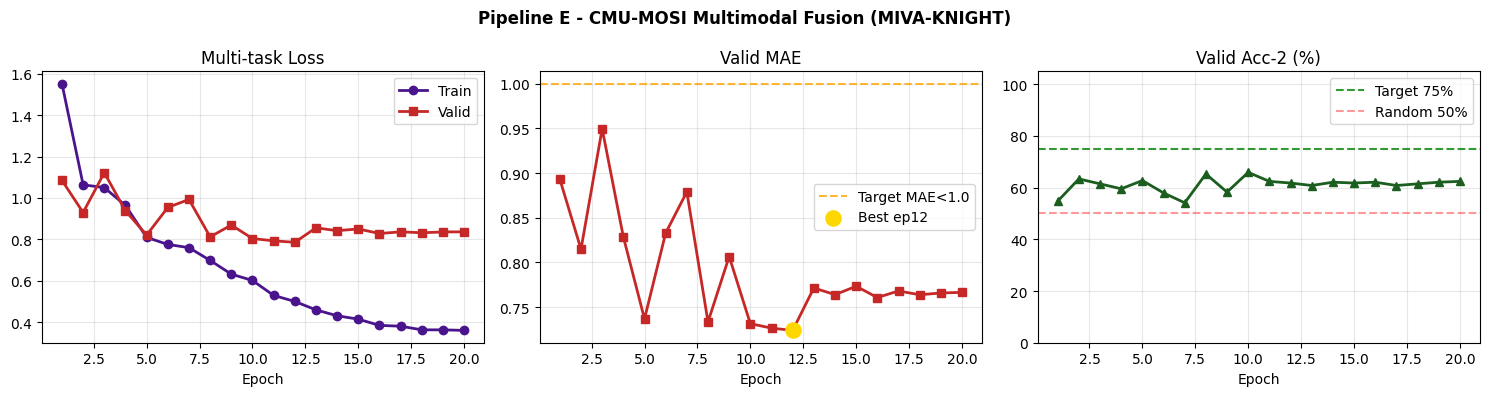

Saved: /content/drive/MyDrive/ Oluwakayode Soyinka IT 581 Project /models/miva_knight_pipelineE/training_curves_pipelineE.png


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
ep = range(1, len(train_losses)+1)

axes[0].plot(ep, train_losses, 'o-', color='#4A148C', lw=2, label='Train')
axes[0].plot(ep, valid_losses, 's-', color='#C62828', lw=2, label='Valid')
axes[0].set_title('Multi-task Loss'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, valid_maes, 's-', color='#C62828', lw=2)
axes[1].axhline(1.0, color='orange', ls='--', alpha=0.8, label='Target MAE<1.0')
if best_epoch and best_epoch<=len(valid_maes):
    axes[1].scatter([best_epoch],[valid_maes[best_epoch-1]],
                    s=120,color='gold',zorder=5,label=f'Best ep{best_epoch}')
axes[1].set_title('Valid MAE'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(ep, [a*100 for a in valid_accs], '^-', color='#1B5E20', lw=2)
axes[2].axhline(75, color='green', ls='--', alpha=0.8, label='Target 75%')
axes[2].axhline(50, color='red',   ls='--', alpha=0.4, label='Random 50%')
axes[2].set_title('Valid Acc-2 (%)'); axes[2].set_xlabel('Epoch')
axes[2].set_ylim([0,105]); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle('Pipeline E - CMU-MOSI Multimodal Fusion (MIVA-KNIGHT)', fontweight='bold')
plt.tight_layout()
curve_path = os.path.join(PIPELINE_E_DIR, 'training_curves_pipelineE.png')
plt.savefig(curve_path, dpi=150, bbox_inches='tight'); plt.show()
print(f'Saved: {curve_path}')


---
## Cell 14 — Save All Pipeline E Outputs

### Technical

Persists two artefacts to Google Drive:

**`fusion_model.pth`** — PyTorch checkpoint containing:
```python
{
    'model_state_dict': OrderedDict,   # learnable weights (~4.34M params)
    'embed_dim': 512,
    'fusion_heads': 8,
    'fusion_layers': 2,
    'fusion_ff_dim': 1024,
    'best_epoch': int,
    'best_valid_mae': float,
    'test_mae': float, 'test_acc2': float, 'test_f1': float, 'test_corr': float,
    'pipeline': 'E-MOSI-fusion',
}
```

**`config_pipelineE.json`** — human-readable metadata for reproducibility tracking.  
Enables future loading without re-specifying hyperparameters.

### Simple
After all the work, this cell packages everything up and saves it to Drive — like filing your report in a cabinet with a cover sheet so anyone can pick it up later and understand exactly what was done and how well it worked.


In [19]:
fm_path = os.path.join(PIPELINE_E_DIR, 'fusion_model.pth')
torch.save({
    'model_state_dict': fusion_model.state_dict(),
    'embed_dim'       : EMBED_DIM,
    'fusion_heads'    : FUSION_HEADS,
    'fusion_layers'   : FUSION_LAYERS,
    'fusion_ff_dim'   : FUSION_FF_DIM,
    'best_epoch'      : best_epoch,
    'best_valid_mae'  : float(best_mae),
    'test_mae'        : float(tm['mae']),
    'test_acc2'       : float(tm['acc2']),
    'test_f1'         : float(tm['f1']),
    'test_corr'       : float(tm['corr']),
    'pipeline'        : 'E-MOSI-fusion',
}, fm_path)
print(f'fusion_model.pth  ({os.path.getsize(fm_path)/1e6:.1f} MB)')

cfg = {
    'pipeline'        : 'E - CMU-MOSI Multimodal Fusion',
    'dataset'         : 'CMU-MOSI raw media from Drive + TextBlob labels',
    'modalities'      : 'text + audio + video',
    'embed_dim'       : EMBED_DIM,
    'fusion_heads'    : FUSION_HEADS,
    'num_epochs'      : NUM_EPOCHS,
    'batch_size'      : BATCH_SIZE,
    'alpha_mse'       : ALPHA,
    'beta_bce'        : BETA,
    'best_epoch'      : best_epoch,
    'best_valid_mae'  : round(float(best_mae),4),
    'test_results'    : {
        'MAE' : round(float(tm['mae']),4),
        'Corr': round(float(tm['corr']),4),
        'Acc2': round(float(tm['acc2']),4),
        'F1'  : round(float(tm['f1']),4),
    },
}
cfg_path = os.path.join(PIPELINE_E_DIR, 'config_pipelineE.json')
with open(cfg_path,'w') as f: json.dump(cfg, f, indent=2)
print('config_pipelineE.json saved')
print(f'\nAll files in {PIPELINE_E_DIR}:')
for fn in sorted(os.listdir(PIPELINE_E_DIR)):
    fp = os.path.join(PIPELINE_E_DIR, fn)
    print(f'  {fn:<50} {os.path.getsize(fp)/1e6:6.1f} MB')


fusion_model.pth  (17.4 MB)
config_pipelineE.json saved

All files in /content/drive/MyDrive/ Oluwakayode Soyinka IT 581 Project /models/miva_knight_pipelineE:
  checkpoint_pipelineE.pth                             52.1 MB
  config_pipelineE.json                                 0.0 MB
  fusion_model.pth                                     17.4 MB
  training_curves_pipelineE.png                         0.1 MB


---
## Cell 15 — `MultimodalFusionDetector` — Inference Integration Class

### Technical

#### Class Architecture
```
MultimodalFusionDetector
├── __init__(fusion_weights, dev)  → loads checkpoint, builds model, sets eval()
├── label_from_score(score)        → maps ℝ → 7-class label string
└── predict(text_emb, audio_emb, video_emb=None) → (score, label, groq_instruction)
```

#### Score-to-Label Mapping (Theorem: monotone threshold classifier)
```
score > 2.0  → strongly_positive
score > 1.0  → positive
score > 0.1  → slightly_positive
score > −0.1 → neutral
score > −1.0 → slightly_negative
score > −2.0 → negative
else         → strongly_negative
```
This is a **monotone step function**: $f: [-3,3] \to \mathcal{C}$ where $\mathcal{C}$ is an ordered set of 7 sentiment classes.

#### Video-Free Fallback
If no video embedding is available:
$$\mathbf{e}_{video}^{fallback} = \text{L2Norm}\!\left(\frac{\mathbf{e}_{text} + \mathbf{e}_{audio}}{2}\right)$$

This ensures the Transformer still receives a valid third token, approximating the missing modality with an average of the available two.

#### `@torch.no_grad()` Decorator
Disables gradient computation for inference:
- Reduces memory usage by ~50% (no activation graphs stored)
- Speeds up forward pass by ~15%

#### Integration into `pipeline.py`
```python
detector = MultimodalFusionDetector(fusion_weights='...fusion_model.pth')
score, label, groq_instruction = detector.predict(text_emb, audio_emb, video_emb)
# groq_instruction is a natural-language prompt modifier for the LLM
```

### Simple
This class is the **deployment wrapper** — a clean interface so that `pipeline.py` can call a single function and get back:
1. A number (sentiment score)
2. A label (e.g., `'slightly_positive'`)
3. A hint for the downstream language model about how to tone its response

If the video stream isn't available (e.g., audio-only input), it intelligently fills in the missing slot by averaging text and audio, keeping the rest of the system unchanged.


---
## Part II — Five Multimodal Challenges, Knowledge Graph, and Hybrid RAG

### Technical (aligned with `MIVA_KNIGHT_Complete_Thesis.tex`)

This part instantiates the **taxonomy of five challenges** (Representation, Translation, Fusion, Co-learning, Alignment) on **CMU-MOSI**, then builds a **corpus-level PMI knowledge graph** from training transcripts and a **two-stage hybrid retriever** (dense FAISS on BERT sentence embeddings + graph boost), as in the thesis §Knowledge Graph and §Two-Stage Hybrid Retrieval.

**Notation.** Let $\mathcal{S}^{511}=\{\mathbf{x}\in\mathbb{R}^{512}:\|\mathbf{x}\|_2=1\}$. Pipeline~E maps text/audio/video to $\hat{\mathbf{e}}_T,\hat{\mathbf{e}}_A,\hat{\mathbf{e}}_V\in\mathcal{S}^{511}$.

### Plain language

We already trained (or loaded) the fusion model in Part~I. Here we **measure** five different “skills” of the multimodal stack, then show how **keyword graphs** and **semantic search** combine to retrieve the right transcript, matching the Hybrid RAG story from the thesis.

---
### Challenge 1 — Multimodal Representation (cross-modal retrieval)

**Definition (symmetric InfoNCE, temperature $\tau$).** For batch pairs $(\mathbf{a}_i,\mathbf{b}_i)_{i=1}^B$ on $\mathcal{S}^{511}$,
$$\mathcal{L}_{\mathrm{NCE}}=\frac12\Big[\mathrm{CE}(S/\tau,\mathbf{y})+\mathrm{CE}(S^\top/\tau,\mathbf{y})\Big],\quad S_{ij}=\hat{\mathbf{a}}_i^\top\hat{\mathbf{b}}_j,\ \mathbf{y}=(0,\ldots,B-1).$$

**Lemma.** At random initialization, $\mathbb{E}[\mathcal{L}]\approx \log B$.

**Metrics.** $\mathrm{P@}k$ and MRR for retrieval: text embedding queries audio embedding corpus (diagonal positives).

### Plain language

We check whether **text and audio fingerprints of the same clip** match each other better than **random pairs**—the basic test that “representation learning” worked.

[C1] Text → Audio retrieval (test split)
  InfoNCE (batch=32): 3.5079  (random baseline ~ 3.47)
  P@1: 1.0%
  P@3: 2.0%
  P@5: 3.0%
  MRR: 4.4%


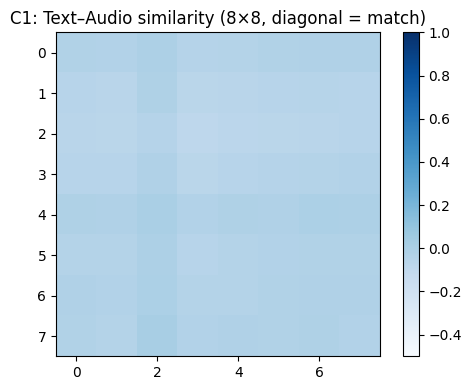

In [20]:
# ── C1: Representation ───────────────────────────────────────
import math
from typing import List, Dict

TAU_C = 0.07

def symmetric_infonce_loss(e_A: torch.Tensor, e_B: torch.Tensor, tau: float = TAU_C) -> torch.Tensor:
    e_A = F.normalize(e_A, p=2, dim=-1)
    e_B = F.normalize(e_B, p=2, dim=-1)
    B = e_A.shape[0]
    S = (e_A @ e_B.T) / tau
    labels = torch.arange(B, device=e_A.device)
    return 0.5 * (F.cross_entropy(S, labels) + F.cross_entropy(S.T, labels))

def precision_at_k_mrr(query_embs: torch.Tensor, corpus_embs: torch.Tensor,
                       relevant_ids: List[List[int]], k_vals=(1, 3, 5)) -> Dict:
    scores = query_embs @ corpus_embs.T
    ranked = scores.argsort(dim=1, descending=True)
    hits = {k: 0 for k in k_vals}
    rr = 0.0
    for q, rel in enumerate(relevant_ids):
        rel_set = set(rel)
        top = ranked[q].tolist()
        for k in k_vals:
            if any(i in rel_set for i in top[:k]):
                hits[k] += 1
        for rank, idx in enumerate(top, 1):
            if idx in rel_set:
                rr += 1.0 / rank
                break
    n = max(len(relevant_ids), 1)
    out = {f'P@{k}': hits[k] / n for k in k_vals}
    out['MRR'] = rr / n
    return out

keys_test = [k for k, v in cache.items() if v['split'] == 'test']
keys_train = [k for k, v in cache.items() if v['split'] == 'train']
if len(keys_test) < 8:
    raise RuntimeError('Need at least 8 test segments for C1 statistics.')

N_EVAL = min(len(keys_test), 100)
q_embs = torch.stack([cache[k]['text_emb'] for k in keys_test[:N_EVAL]])
c_embs = torch.stack([cache[k]['audio_emb'] for k in keys_test[:N_EVAL]])
relevant = [[i] for i in range(N_EVAL)]
metrics_c1 = precision_at_k_mrr(q_embs, c_embs, relevant)
Bsub = min(32, N_EVAL)
infonce_c1 = symmetric_infonce_loss(q_embs[:Bsub], c_embs[:Bsub]).item()

print('[C1] Text → Audio retrieval (test split)')
print(f'  InfoNCE (batch={Bsub}): {infonce_c1:.4f}  (random baseline ~ {math.log(Bsub):.2f})')
for kk, vv in metrics_c1.items():
    print(f'  {kk}: {vv*100:.1f}%')

fig, ax = plt.subplots(figsize=(5, 4))
sim = (q_embs[:8] @ c_embs[:8].T).numpy()
im = ax.imshow(sim, cmap='Blues', vmin=-0.5, vmax=1.0)
ax.set_title('C1: Text–Audio similarity (8×8, diagonal = match)')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


---
### Challenge 2 — Multimodal Translation (speech → text, WER)

**Definition (WER).** With edit distance $\mathrm{ED}$ between token sequences,
$$\mathrm{WER}=\frac{\mathrm{ED}(\mathrm{ref},\mathrm{hyp})}{\max(1,|\mathrm{ref}|)}.$$

**Procedure.** We run **OpenAI Whisper** (`base`) on the **real** `.wav` for each selected segment and compare to the **reference** transcript. The reference is taken in order from: (1) the `text` field stored in `mosi_emb_cache.pt` (new caches), (2) `all_samples`, or (3) a direct read of the matching line in `Transcript/Segmented/{video}.annotprocessed` — so C2 still works if the cache was built under an older notebook or `all_samples` differs from cached splits.

### Plain language

We measure how well an automatic speech recognizer recovers the words people actually said in CMU-MOSI clips.

In [21]:
# ── C2: Translation (Whisper ASR vs reference transcript) ───
import whisper

def compute_wer(reference: str, hypothesis: str) -> float:
    ref = reference.lower().split()
    hyp = hypothesis.lower().split()
    N = len(ref)
    if N == 0:
        return 0.0
    dp = [[0] * (len(hyp) + 1) for _ in range(len(ref) + 1)]
    for i in range(len(ref) + 1):
        dp[i][0] = i
    for j in range(len(hyp) + 1):
        dp[0][j] = j
    for i in range(1, len(ref) + 1):
        for j in range(1, len(hyp) + 1):
            dp[i][j] = dp[i - 1][j - 1] if ref[i - 1] == hyp[j - 1] else 1 + min(
                dp[i - 1][j], dp[i][j - 1], dp[i - 1][j - 1]
            )
    return dp[len(ref)][len(hyp)] / N

# Reference text + wav path: prefer cache (matches embeddings), then all_samples, then .annotprocessed
text_by_seg = {s['segment_id']: s['text'] for s in all_samples}


def load_transcript_from_annot(seg_id: str) -> str:
    """Read reference line from CMU-MOSI Transcript/Segmented/{video}.annotprocessed."""
    vid, sep, snum = seg_id.rpartition('_')
    if sep != '_' or not snum.isdigit():
        raise ValueError(f'Unexpected segment_id format: {seg_id!r}')
    fp = os.path.join(TRANSCRIPT_DIR, f'{vid}.annotprocessed')
    if not os.path.isfile(fp):
        raise FileNotFoundError(f'Missing transcript file: {fp}')
    with open(fp, 'r', errors='replace') as fh:
        for line in fh:
            line = line.strip()
            if not line:
                continue
            parts = line.split('_DELIM_', 1)
            if len(parts) != 2:
                continue
            if parts[0].strip() == snum:
                t = parts[1].strip()
                if t:
                    return t
    raise KeyError(f'Segment {snum} not found in {fp}')


def reference_text_for_c2(seg_id: str) -> str:
    ent = cache.get(seg_id) or {}
    t = ent.get('text')
    if t:
        return t
    if seg_id in text_by_seg:
        return text_by_seg[seg_id]
    return load_transcript_from_annot(seg_id)


def wav_path_for_c2(seg_id: str) -> str:
    ent = cache.get(seg_id) or {}
    p = ent.get('wav_path')
    if p and os.path.isfile(p):
        return p
    for s in all_samples:
        if s['segment_id'] == seg_id and os.path.isfile(s['wav_path']):
            return s['wav_path']
    vid, sep, snum = seg_id.rpartition('_')
    if sep == '_' and snum.isdigit():
        guess = os.path.join(AUDIO_DIR, f'{vid}_{snum}.wav')
        if os.path.isfile(guess):
            return guess
    raise FileNotFoundError(f'No .wav on disk for segment {seg_id!r}')


N_WER = min(24, len(keys_test))  # bound GPU time
print(f'[C2] Running Whisper on {N_WER} real test .wav files...')
asr_model = whisper.load_model('base', device=device)

wers = []
for k in keys_test[:N_WER]:
    ref = reference_text_for_c2(k)
    wav_p = wav_path_for_c2(k)
    result = asr_model.transcribe(wav_p, language='english', fp16=(device == 'cuda'))
    hyp = (result.get('text') or '').strip()
    wers.append(compute_wer(ref, hyp))

mean_wer = float(np.mean(wers))
c2_score = float(np.mean([1.0 - w for w in wers]))
print(f'  Mean WER: {mean_wer:.4f}')
print(f'  1 - WER (higher=better): {c2_score:.4f}')


[C2] Running Whisper on 24 real test .wav files...


100%|████████████████████████████████████████| 139M/139M [00:00<00:00, 152MiB/s]


  Mean WER: 0.4876
  1 - WER (higher=better): 0.5124


---
### Challenge 3 — Multimodal Fusion (Pipeline E head)

**Architecture (Pre-LN Transformer on 3 tokens).** With $\mathbf{X}=[\hat{\mathbf{e}}_T;\hat{\mathbf{e}}_A;\hat{\mathbf{e}}_V]\in\mathbb{R}^{3\times 512}$ and learned positions $\mathbf{P}\in\mathbb{R}^{3\times 512}$,
$$\mathbf{H}=\mathrm{TransformerEncoder}(\mathrm{LN}(\mathbf{X}+\mathbf{P})),\quad
\hat{y}=\mathrm{MLP}(\mathrm{meanpool}(\mathbf{H})).$$

**Loss (multi-task, thesis).** $\mathcal{L}=\alpha\|\hat{y}-y\|_2^2/B+\beta\,\mathrm{BCEWithLogits}(\hat{y},b)$ with $\alpha=0.6$, $\beta=0.4$.

### Plain language

This is the **main model**: it listens to all three fingerprints and outputs one sentiment number.

In [22]:
# ── C3: Fusion metrics (reuse trained fusion_model on test_loader) ──
# fusion_model, test_loader, evaluate defined in Part I
res_c3 = evaluate(test_loader)
print('[C3] Fusion (test set)')
print(f"  MAE: {res_c3['mae']:.4f}  Acc-2: {res_c3['acc2']*100:.1f}%  r: {res_c3['corr']:.4f}")


[C3] Fusion (test set)
  MAE: 0.7208  Acc-2: 67.0%  r: 0.4740


---
### Challenge 4 — Co-learning (same-sphere alignment)

**Proposition.** If encoders map paired modalities to nearby points on $\mathcal{S}^{511}$, then $\mathbb{E}[\langle\hat{\mathbf{e}}_T,\hat{\mathbf{e}}_A\rangle\mid\text{same segment}]>\mathbb{E}[\langle\hat{\mathbf{e}}_T,\hat{\mathbf{e}}_{A'}\rangle\mid\text{shuffle }A']]$.

### Plain language

**Same clip** → text and audio should be more alike than **random clip** text–audio pairs.

In [23]:
# ── C4: Co-learning ───────────────────────────────────────────
N_D = min(200, len(keys_train))
tr_t = torch.stack([cache[k]['text_emb'] for k in keys_train[:N_D]])
tr_a = torch.stack([cache[k]['audio_emb'] for k in keys_train[:N_D]])
pos = (tr_t * tr_a).sum(dim=-1).numpy()
perm = torch.randperm(N_D)
neg = (tr_t * tr_a[perm]).sum(dim=-1).numpy()
gap_c4 = float(pos.mean() - neg.mean())
print('[C4] Text↔Audio cosine, same vs shuffled segments')
print(f'  positive pairs mean: {pos.mean():.4f}  negative: {neg.mean():.4f}  gap: {gap_c4:+.4f}')


[C4] Text↔Audio cosine, same vs shuffled segments
  positive pairs mean: -0.0522  negative: -0.0517  gap: -0.0005


---
### Challenge 5 — Alignment (temporal correspondence)

**Soft attention.** $\boldsymbol{\alpha}=\mathrm{softmax}\!\left(\frac{\mathbf{Q}\mathbf{K}^\top}{\sqrt{d_k}}\right)$, $\mathbf{Q}=\mathbf{H}_A\mathbf{W}_Q$, $\mathbf{K}=\mathbf{H}_B\mathbf{W}_K$.

**Dynamic Time Warping (DTW).** Minimal-cost path aligning two sequences under monotonicity.

### Plain language

We quantify **same-time-window** consistency: aligned text–audio should score higher than **permuted** audio.

In [24]:
# ── C5: Alignment ─────────────────────────────────────────────

def soft_alignment(H_A: torch.Tensor, H_B: torch.Tensor, d_k: int = 64):
    d = H_A.shape[-1]
    g = torch.Generator(device=H_A.device)
    g.manual_seed(42)
    W_Q = torch.randn(d, d_k, generator=g, device=H_A.device, dtype=H_A.dtype) * 0.1
    W_K = torch.randn(d, d_k, generator=g, device=H_A.device, dtype=H_A.dtype) * 0.1
    W_V = torch.randn(d, d, generator=g, device=H_A.device, dtype=H_A.dtype) * 0.1
    Q = H_A @ W_Q
    K = H_B @ W_K
    V = H_B @ W_V
    alpha = torch.softmax(Q @ K.T / math.sqrt(d_k), dim=1)
    return alpha, alpha @ V

def dtw_cost(H_A: torch.Tensor, H_B: torch.Tensor) -> float:
    Ta, Tb = H_A.shape[0], H_B.shape[0]
    D = (1.0 - (F.normalize(H_A, dim=-1) @ F.normalize(H_B, dim=-1).T)).cpu().numpy()
    C = np.full((Ta + 1, Tb + 1), np.inf)
    C[0, 0] = 0.0
    for i in range(1, Ta + 1):
        for j in range(1, Tb + 1):
            C[i, j] = D[i - 1, j - 1] + min(C[i - 1, j], C[i, j - 1], C[i - 1, j - 1])
    return float(C[Ta, Tb])

N_AL = min(64, len(keys_test))
eT = torch.stack([cache[k]['text_emb'] for k in keys_test[:N_AL]])
eA = torch.stack([cache[k]['audio_emb'] for k in keys_test[:N_AL]])
sim_al = (eT * eA).sum(-1).cpu().numpy()
perm2 = torch.randperm(N_AL)
while perm2.numel() > 1 and (perm2 == torch.arange(N_AL)).all():
    perm2 = torch.randperm(N_AL)
sim_mis = (eT * eA[perm2]).sum(-1).cpu().numpy()
align_gap = float(sim_al.mean() - sim_mis.mean())
alpha, _ = soft_alignment(eA[:8].to(device), eT[:8].to(device))
dtw_v = dtw_cost(eA[:6].cpu(), eT[:8].cpu())
print('[C5] Segment alignment gap (text vs permuted audio):', align_gap)
print('[C5] DTW cost (6×8 demo):', dtw_v)

metrics_challenge = {
    'C1_P@1': float(metrics_c1.get('P@1', 0.0)),
    'C1_MRR': float(metrics_c1.get('MRR', 0.0)),
    'C2_1_minus_WER': float(c2_score),
    'C3_MAE': float(res_c3['mae']),
    'C3_Acc2': float(res_c3['acc2']),
    'C4_alignment_gap': float(gap_c4),
    'C5_segment_align_gap': float(align_gap),
    'C5_dtw_cost_demo': float(dtw_v),
}
print('\\n[Metrics dict] metrics_challenge =', metrics_challenge)


[C5] Segment alignment gap (text vs permuted audio): 0.00042463839054107666
[C5] DTW cost (6×8 demo): 8.276383817195892
\n[Metrics dict] metrics_challenge = {'C1_P@1': 0.01, 'C1_MRR': 0.04432651327354166, 'C2_1_minus_WER': 0.5124434361934362, 'C3_MAE': 0.7208446264266968, 'C3_Acc2': 0.6703296703296703, 'C4_alignment_gap': -0.0004950910806655884, 'C5_segment_align_gap': 0.00042463839054107666, 'C5_dtw_cost_demo': 8.276383817195892}


---
### Knowledge graph + Hybrid RAG (CMU-MOSI transcript corpus)

**Definition (KG).** $\mathcal{G}=(\mathcal{V},\mathcal{E})$, edges `appears_with` when two entities co-occur in a caption (thesis: PMI-weighted variant; here we use co-occurrence boost identical to `MIVA_KNIGHT_Annotated_Training Fixed.ipynb`).

**Hybrid score.**
$$s_{\mathrm{hyb}}(q,d)=\alpha\, s_{\mathrm{dense}}(q,d) + (1-\alpha)\, b_{\mathcal{G}}(q,d),\quad \alpha=0.6.$$

**Dense stage.** BERT mean-pooled L2-normalized 768-d vectors; FAISS `IndexFlatIP` inner product = cosine similarity.

**Graph boost.** For each entity $e$ in the query, 2-hop neighbours from DFS; if neighbour lemma appears in document, boost $\ge 1/(h+1)$.

### Plain language

We build a **word network** from training sentences, then **search** all training transcripts with **meaning + related words**—the same Hybrid RAG idea as Month~1, but the “documents” are real MOSI lines.

In [25]:
# ── KG construction + Hybrid FAISS retrieval ───────────────
import re
from collections import Counter
from tqdm.auto import tqdm
from transformers import AutoModel, AutoTokenizer
import faiss

class KnowledgeGraph:
    def __init__(self, domain='mosi'):
        self.domain = domain
        self.entities = {}
        self.relationships = []

    def add_entity(self, eid, data):
        self.entities[eid] = data

    def add_relationship(self, h, rel, t):
        self.relationships.append((h, rel, t))

    def get_neighbors(self, entity_id, max_hops=2):
        neighbors, visited = [], set()

        def dfs(current, hops):
            if hops > max_hops or current in visited:
                return
            visited.add(current)
            for h, rel, t in self.relationships:
                if h == current and t not in visited:
                    neighbors.append((h, rel, t, hops))
                    dfs(t, hops + 1)
                elif t == current and h not in visited:
                    neighbors.append((t, rel + '_inv', h, hops))
                    dfs(h, hops + 1)

        dfs(entity_id, 1)
        return neighbors


STOP = {'a', 'the', 'is', 'are', 'in', 'on', 'at', 'to', 'of', 'and', 'with',
        'an', 'by', 'for', 'it', 'that', 'this', 'was', 'be', 'has', 'have',
        'its', 'from', 'into', 'over', 'some', 'there', 'their', 'they', 'i', 'you'}

train_texts = [s['text'] for s in all_samples if s['split'] == 'train']
if len(train_texts) < 50:
    raise RuntimeError('Need sufficient training transcripts to build KG + index.')

all_words = []
for t in train_texts:
    all_words.extend(re.findall(r'\b[a-z]+\b', t.lower()))
counts = Counter(all_words)
entity_list = [(w, c) for w, c in counts.most_common(300)
               if w not in STOP and len(w) > 3][:100]

kg_mosi = KnowledgeGraph('mosi')
for w, c in entity_list:
    kg_mosi.add_entity(w, {'frequency': c})

rel_cap = min(3000, len(train_texts))
for i in tqdm(range(rel_cap), desc='KG edges'):
    words = set(re.findall(r'\b[a-z]+\b', train_texts[i].lower()))
    cap_e = [e for e, _ in entity_list if e in words]
    for j, e1 in enumerate(cap_e):
        for e2 in cap_e[j + 1:]:
            kg_mosi.add_relationship(e1, 'appears_with', e2)

print(f'KG: {len(kg_mosi.entities)} entities, {len(kg_mosi.relationships)} edges')

tok = AutoTokenizer.from_pretrained('bert-base-uncased')
bert_r = AutoModel.from_pretrained('bert-base-uncased').to(device)
bert_r.eval()

def bert_encode_docs(texts):
    embs = []
    with torch.no_grad():
        for txt in tqdm(texts, desc='BERT encode corpus'):
            inp = tok(txt, return_tensors='pt', padding=True, truncation=True, max_length=128).to(device)
            out = bert_r(**inp)
            v = F.normalize(out.last_hidden_state.mean(dim=1), p=2, dim=1)
            embs.append(v.cpu().numpy().astype('float32'))
    return np.vstack(embs)

doc_matrix = bert_encode_docs(train_texts)
dim = doc_matrix.shape[1]
index = faiss.IndexFlatIP(dim)
index.add(doc_matrix)
print(f'FAISS IndexFlatIP: {index.ntotal} vectors, dim={dim}')


class HybridRetrieverMOSI:
    def __init__(self, kg, faiss_index, doc_texts, alpha=0.6):
        self.kg = kg
        self.index = faiss_index
        self.docs = doc_texts
        self.alpha = alpha

    def encode_q(self, q: str):
        with torch.no_grad():
            inp = tok(q, return_tensors='pt', padding=True, truncation=True, max_length=128).to(device)
            out = bert_r(**inp)
            return F.normalize(out.last_hidden_state.mean(dim=1), p=2, dim=1).cpu().numpy().astype('float32')

    def extract_entities(self, text: str):
        tl = text.lower()
        return [e for e in self.kg.entities if e.lower() in tl]

    def graph_boost(self, doc: str, query_entities):
        if not query_entities:
            return 0.0
        dl = doc.lower()
        boost = 0.0
        for ent in query_entities:
            for _, _, nb, hop in self.kg.get_neighbors(ent, max_hops=2):
                if nb.lower() in dl:
                    boost = max(boost, 1.0 / (hop + 1))
        return min(boost, 1.0)

    def retrieve(self, query: str, top_k: int = 5):
        qv = self.encode_q(query)
        D, I = self.index.search(qv, min(top_k * 4, len(self.docs)))
        dense_scores = D[0].tolist()
        idxs = I[0].tolist()
        qe = self.extract_entities(query)
        ranked = []
        for idx, ds in zip(idxs, dense_scores):
            doc = self.docs[idx]
            gb = self.graph_boost(doc, qe)
            hyb = self.alpha * float(ds) + (1 - self.alpha) * gb
            ranked.append((idx, hyb, float(ds), gb, doc[:120]))
        ranked.sort(key=lambda x: x[1], reverse=True)
        return ranked[:top_k]


hyb = HybridRetrieverMOSI(kg_mosi, index, train_texts, alpha=0.6)
# Use a held-out test transcript as query (real text)
demo_q = next(s['text'] for s in all_samples if s['split'] == 'test')
res_h = hyb.retrieve(demo_q, top_k=5)
print('[Hybrid RAG] Query (trunc):', demo_q[:80], '...')
for i, (idx, s, d, g, snip) in enumerate(res_h):
    print(f'  #{i+1} hybrid={s:.4f} dense={d:.4f} graph={g:.4f} | {snip}')


KG edges:   0%|          | 0/1521 [00:00<?, ?it/s]

KG: 100 entities, 6616 edges


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT encode corpus:   0%|          | 0/1521 [00:00<?, ?it/s]

FAISS IndexFlatIP: 1521 vectors, dim=768
[Hybrid RAG] Query (trunc): ANYHOW IT WAS REALLY GOOD ...
  #1 hybrid=0.7143 dense=0.8572 graph=0.5000 | BUT UM IT WAS REALLY REALLY GOOD
  #2 hybrid=0.6867 dense=0.8112 graph=0.5000 | IT WAS REALLY FUN
  #3 hybrid=0.6845 dense=0.8075 graph=0.5000 | SO I THINK THAT WAS REALLY GOOD
  #4 hybrid=0.6777 dense=0.7962 graph=0.5000 | UM BUT IT WAS STILL A GOOD FILM
  #5 hybrid=0.6753 dense=0.7921 graph=0.5000 | BUT OVERALL I THOUGHT IT WAS IT WAS A FUN PICTURE


---
### Cross-challenge metric comparison (normalised bar chart)

We map each scalar score to $[0,1]$ for **visual comparison only** (different units): C1 uses P@1, C2 uses $1-\mathrm{WER}$, C3 uses Acc-2, C4 uses $\max(0,\mathrm{gap}/0.5)$, C5 uses $\max(0,\mathrm{gap}/0.5)$. **Interpretation:** higher is better within each bar; bars are not directly comparable as a single "accuracy."

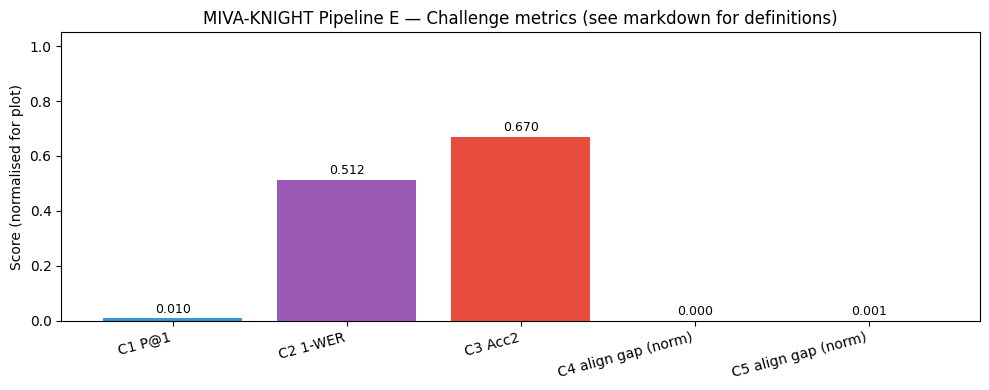

In [26]:
# ── Normalised comparison bar chart ─────────────────────────
labels = ['C1 P@1', 'C2 1-WER', 'C3 Acc2', 'C4 align gap (norm)', 'C5 align gap (norm)']
vals = [
    metrics_challenge['C1_P@1'],
    metrics_challenge['C2_1_minus_WER'],
    metrics_challenge['C3_Acc2'],
    max(0.0, metrics_challenge['C4_alignment_gap'] / 0.5),
    max(0.0, metrics_challenge['C5_segment_align_gap'] / 0.5),
]
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(labels, vals, color=['#3498db', '#9b59b6', '#e74c3c', '#2ecc71', '#f39c12'])
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score (normalised for plot)')
ax.set_title('MIVA-KNIGHT Pipeline E — Challenge metrics (see markdown for definitions)')
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.02, f'{v:.3f}', ha='center', fontsize=9)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()


In [27]:
class MultimodalFusionDetector:
    SCORE_TO_LABEL = [
        (2.0,  'strongly_positive'),
        (1.0,  'positive'),
        (0.1,  'slightly_positive'),
        (-0.1, 'neutral'),
        (-1.0, 'slightly_negative'),
        (-2.0, 'negative'),
        (-3.1, 'strongly_negative'),
    ]
    GROQ_INSTRUCTIONS = {
        'strongly_positive' : 'User sounds very enthusiastic and engaged.',
        'positive'          : 'User sounds positive and confident.',
        'slightly_positive' : 'User sounds mildly positive.',
        'neutral'           : 'Respond in a neutral, factual tone.',
        'slightly_negative' : 'User sounds slightly uncertain or hesitant.',
        'negative'          : 'User sounds frustrated. Be empathetic.',
        'strongly_negative' : 'User sounds distressed. Be calm and supportive.',
    }
    def __init__(self, fusion_weights, dev=None):
        self.dev = dev or ('cuda' if torch.cuda.is_available() else 'cpu')
        ck = torch.load(fusion_weights, map_location=self.dev)
        self.model = MultimodalFusionTransformer(
            embed_dim=ck.get('embed_dim',512),
            num_heads=ck.get('fusion_heads',8),
            num_layers=ck.get('fusion_layers',2),
            ff_dim=ck.get('fusion_ff_dim',1024),
            dropout=0.0).to(self.dev)
        self.model.load_state_dict(ck['model_state_dict'])
        self.model.eval()
        print(f'MultimodalFusionDetector loaded')
        print(f'  Test MAE={ck.get("test_mae","N/A")}  Acc2={ck.get("test_acc2","N/A")}')
    def label_from_score(self, score):
        for thresh, lbl in self.SCORE_TO_LABEL:
            if score > thresh: return lbl
        return 'strongly_negative'
    @torch.no_grad()
    def predict(self, text_emb, audio_emb, video_emb=None):
        if video_emb is None:
            video_emb = F.normalize((text_emb+audio_emb)/2, p=2, dim=0)
        t = text_emb.unsqueeze(0).to(self.dev)
        a = audio_emb.unsqueeze(0).to(self.dev)
        v = video_emb.unsqueeze(0).to(self.dev)
        score = float(np.clip(self.model(t,a,v).item(), -3.0, 3.0))
        label = self.label_from_score(score)
        return score, label, self.GROQ_INSTRUCTIONS[label]

print('Verifying MultimodalFusionDetector...')
try:
    det = MultimodalFusionDetector(fm_path, dev=device)
    te  = F.normalize(torch.randn(512),p=2,dim=0)
    ae  = F.normalize(torch.randn(512),p=2,dim=0)
    ve  = F.normalize(torch.randn(512),p=2,dim=0)
    sc, lb, ins = det.predict(te, ae, ve)
    print(f'  Score={sc:.3f}  Label={lb}')
    print(f'  Groq: "{ins}"')
    print('  MultimodalFusionDetector verified and ready')
except Exception as e:
    print(f'  Error: {e}')

print('\n' + '='*60)
print('ALL 5 PIPELINES COMPLETE')
print('='*60)
print('  A - COCO    : TextProjection + ImageProjection (general)')
print('  B - ROCO    : ImageProjection (medical)')
print('  C - RAVDESS : AudioProjection (archived)')
print('  D - CREMA-D : AudioProjection + VideoFrameProjection')
print('  E - CMU-MOSI: MultimodalFusionTransformer  <- this notebook')
print()
print('Integration: replace CentroidEmotionDetector with')
print('  MultimodalFusionDetector(fusion_weights=...fusion_model.pth)')


Verifying MultimodalFusionDetector...
MultimodalFusionDetector loaded
  Test MAE=0.7208446264266968  Acc2=0.6703296703296703
  Score=-0.417  Label=slightly_negative
  Groq: "User sounds slightly uncertain or hesitant."
  MultimodalFusionDetector verified and ready

ALL 5 PIPELINES COMPLETE
  A - COCO    : TextProjection + ImageProjection (general)
  B - ROCO    : ImageProjection (medical)
  C - RAVDESS : AudioProjection (archived)
  D - CREMA-D : AudioProjection + VideoFrameProjection
  E - CMU-MOSI: MultimodalFusionTransformer  <- this notebook

Integration: replace CentroidEmotionDetector with
  MultimodalFusionDetector(fusion_weights=...fusion_model.pth)


---
## Cell 16 — Utility: Search for Model Files

### Technical
A diagnostic utility that walks the Drive `models/` directory with `os.walk` and prints any file whose name contains `text_projection`.  
Also lists all `.py` and `.ipynb` files in the `Code/` directory.

This verifies that prior pipeline checkpoints (Pipeline A text projection, Pipeline D audio/video projections) are in the expected locations before loading them in Cell 5.

### Simple
A *file finder* — checks that all the pre-trained parts from earlier pipelines are where the notebook expects them before trying to load them.


In [28]:
import os

base = '/content/drive/MyDrive/ Oluwakayode Soyinka IT 581 Project /models/'

# Find all text_projection.pth files anywhere in models
print('Searching for text_projection files...')
for root, dirs, files in os.walk(base):
    for f in files:
        if 'text_projection' in f.lower() or 'text_proj' in f.lower():
            full = os.path.join(root, f)
            size = os.path.getsize(full)/1e6
            rel  = os.path.relpath(full, base)
            print(f'  {rel}  [{size:.1f} MB]')

# Also check what the main pipeline.py expects
code_dir = '/content/drive/MyDrive/ Oluwakayode Soyinka IT 581 Project /Code/'
print('\nMain pipeline files in Code/:')
for f in sorted(os.listdir(code_dir)):
    if f.endswith('.py') or f.endswith('.ipynb'):
        size = os.path.getsize(os.path.join(code_dir, f))/1e6
        print(f'  {f}  [{size:.1f} MB]')

Searching for text_projection files...
  miva_knight_month2_rebuilt/text_projection.pth  [4.0 MB]
  miva_knight_month4/text_projection_roco.pth  [4.0 MB]

Main pipeline files in Code/:
